In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [52]:
full_data = pd.read_csv('dataset_final_clima_completo.csv')

In [53]:
numerical_features = full_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = full_data.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", numerical_features)
print("Categóricas:", categorical_features)

Numéricas: ['año', 'mes', 'rendimiento', 'temperatura_celsius', 'precipitacion_mm', 'suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 'produccion', 'sup_sembrada']
Categóricas: ['provincia_nombre', 'departamento_nombre', 'departamento_id', 'cultivo', 'suelo_alcalin_s1']


## 🎯 Análisis de Correlación con Variable Objetivo (Rendimiento)

Este análisis muestra la relación entre cada feature y la variable objetivo que queremos predecir.

In [54]:
# Análisis de correlación con variable objetivo
print("="*80)
print("CORRELACIÓN DE TODAS LAS FEATURES CON RENDIMIENTO (Variable Objetivo)")
print("="*80)

if 'rendimiento' in numerical_features:
    # Calcular correlaciones
    correlations = full_data[numerical_features].corr()['rendimiento'].drop('rendimiento').sort_values(ascending=False)
    
    print("\n📊 CORRELACIONES (Pearson):")
    print("="*80)
    
    # Crear DataFrame para mejor visualización
    corr_df = pd.DataFrame({
        'Feature': correlations.index,
        'Correlación': correlations.values,
        'Correlación Abs': np.abs(correlations.values),
        'Interpretación': [
            'Muy Fuerte' if abs(c) >= 0.7 else 
            'Fuerte' if abs(c) >= 0.5 else 
            'Moderada' if abs(c) >= 0.3 else 
            'Débil' if abs(c) >= 0.1 else 
            'Muy Débil' for c in correlations.values
        ]
    })
    
    print(corr_df.to_string(index=False))
    
    # Clasificar correlaciones
    print("\n" + "="*80)
    print("CLASIFICACIÓN DE CORRELACIONES:")
    print("="*80)
    
    muy_fuerte = corr_df[corr_df['Correlación Abs'] >= 0.7]
    fuerte = corr_df[(corr_df['Correlación Abs'] >= 0.5) & (corr_df['Correlación Abs'] < 0.7)]
    moderada = corr_df[(corr_df['Correlación Abs'] >= 0.3) & (corr_df['Correlación Abs'] < 0.5)]
    debil = corr_df[(corr_df['Correlación Abs'] >= 0.1) & (corr_df['Correlación Abs'] < 0.3)]
    muy_debil = corr_df[corr_df['Correlación Abs'] < 0.1]
    
    print(f"\n✅ Muy Fuerte (|r| ≥ 0.7): {len(muy_fuerte)} features")
    if len(muy_fuerte) > 0:
        for idx, row in muy_fuerte.iterrows():
            print(f"   - {row['Feature']}: {row['Correlación']:.4f}")
    
    print(f"\n🟢 Fuerte (0.5 ≤ |r| < 0.7): {len(fuerte)} features")
    if len(fuerte) > 0:
        for idx, row in fuerte.iterrows():
            print(f"   - {row['Feature']}: {row['Correlación']:.4f}")
    
    print(f"\n🟡 Moderada (0.3 ≤ |r| < 0.5): {len(moderada)} features")
    if len(moderada) > 0:
        for idx, row in moderada.iterrows():
            print(f"   - {row['Feature']}: {row['Correlación']:.4f}")
    
    print(f"\n🟠 Débil (0.1 ≤ |r| < 0.3): {len(debil)} features")
    if len(debil) > 0:
        for idx, row in debil.iterrows():
            print(f"   - {row['Feature']}: {row['Correlación']:.4f}")
    
    print(f"\n🔴 Muy Débil (|r| < 0.1): {len(muy_debil)} features")
    if len(muy_debil) > 0:
        for idx, row in muy_debil.iterrows():
            print(f"   - {row['Feature']}: {row['Correlación']:.4f}")
else:
    print("⚠️ Variable 'rendimiento' no encontrada en features numéricas")

CORRELACIÓN DE TODAS LAS FEATURES CON RENDIMIENTO (Variable Objetivo)

📊 CORRELACIONES (Pearson):
            Feature  Correlación  Correlación Abs Interpretación
         produccion     0.343133         0.343133       Moderada
   suelo_profund_s1     0.066852         0.066852      Muy Débil
   precipitacion_mm     0.062912         0.062912      Muy Débil
temperatura_celsius     0.051436         0.051436      Muy Débil
                año     0.043636         0.043636      Muy Débil
       sup_sembrada     0.017863         0.017863      Muy Débil
                mes     0.000291         0.000291      Muy Débil
     suelo_ind_prod    -0.015517         0.015517      Muy Débil
    suelo_porc_sue1    -0.179211         0.179211          Débil

CLASIFICACIÓN DE CORRELACIONES:

✅ Muy Fuerte (|r| ≥ 0.7): 0 features

🟢 Fuerte (0.5 ≤ |r| < 0.7): 0 features

🟡 Moderada (0.3 ≤ |r| < 0.5): 1 features
   - produccion: 0.3431

🟠 Débil (0.1 ≤ |r| < 0.3): 1 features
   - suelo_porc_sue1: -0.1792

🔴 Muy

VISUALIZACIÓN: CORRELACIONES CON RENDIMIENTO


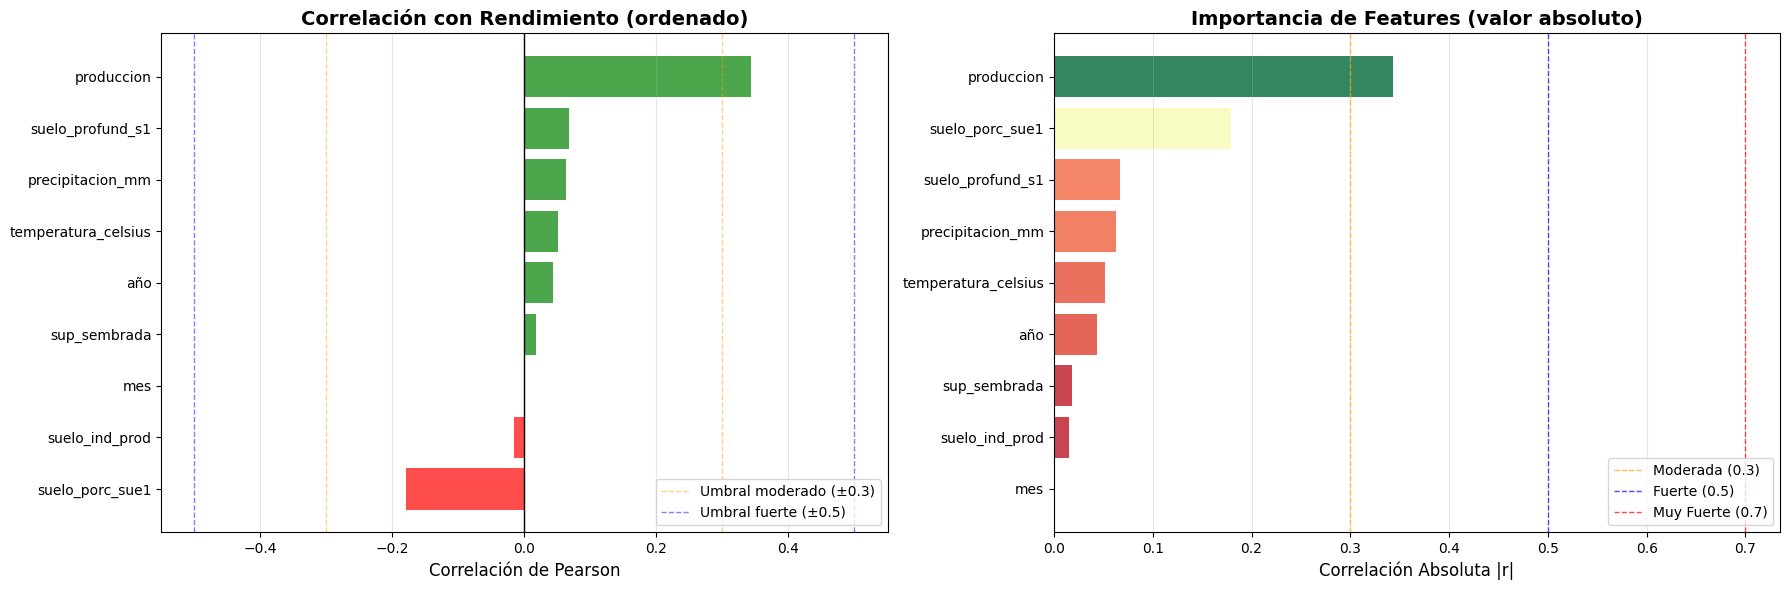

In [55]:
# Visualización de correlaciones con rendimiento
print("="*80)
print("VISUALIZACIÓN: CORRELACIONES CON RENDIMIENTO")
print("="*80)

if 'rendimiento' in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Gráfico 1: Barras horizontales ordenadas
    correlations_sorted = correlations.sort_values()
    colors = ['green' if x > 0 else 'red' for x in correlations_sorted.values]
    
    axes[0].barh(range(len(correlations_sorted)), correlations_sorted.values, color=colors, alpha=0.7)
    axes[0].set_yticks(range(len(correlations_sorted)))
    axes[0].set_yticklabels(correlations_sorted.index)
    axes[0].set_xlabel('Correlación de Pearson', fontsize=12)
    axes[0].set_title('Correlación con Rendimiento (ordenado)', fontsize=14, fontweight='bold')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[0].axvline(x=0.3, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Umbral moderado (±0.3)')
    axes[0].axvline(x=-0.3, color='orange', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].axvline(x=0.5, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='Umbral fuerte (±0.5)')
    axes[0].axvline(x=-0.5, color='blue', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].legend(loc='lower right')
    
    # Gráfico 2: Valor absoluto ordenado
    correlations_abs = correlations.abs().sort_values(ascending=True)
    colors_abs = plt.cm.RdYlGn(correlations_abs.values / correlations_abs.max())
    
    axes[1].barh(range(len(correlations_abs)), correlations_abs.values, color=colors_abs, alpha=0.8)
    axes[1].set_yticks(range(len(correlations_abs)))
    axes[1].set_yticklabels(correlations_abs.index)
    axes[1].set_xlabel('Correlación Absoluta |r|', fontsize=12)
    axes[1].set_title('Importancia de Features (valor absoluto)', fontsize=14, fontweight='bold')
    axes[1].axvline(x=0.3, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Moderada (0.3)')
    axes[1].axvline(x=0.5, color='blue', linestyle='--', linewidth=1, alpha=0.7, label='Fuerte (0.5)')
    axes[1].axvline(x=0.7, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Muy Fuerte (0.7)')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

RELACIONES BIVARIADAS: TOP FEATURES CORRELACIONADAS

Visualizando las 6 features más correlacionadas con rendimiento:

  - produccion: r = 0.3431
  - suelo_porc_sue1: r = -0.1792
  - suelo_profund_s1: r = 0.0669
  - precipitacion_mm: r = 0.0629
  - temperatura_celsius: r = 0.0514
  - año: r = 0.0436


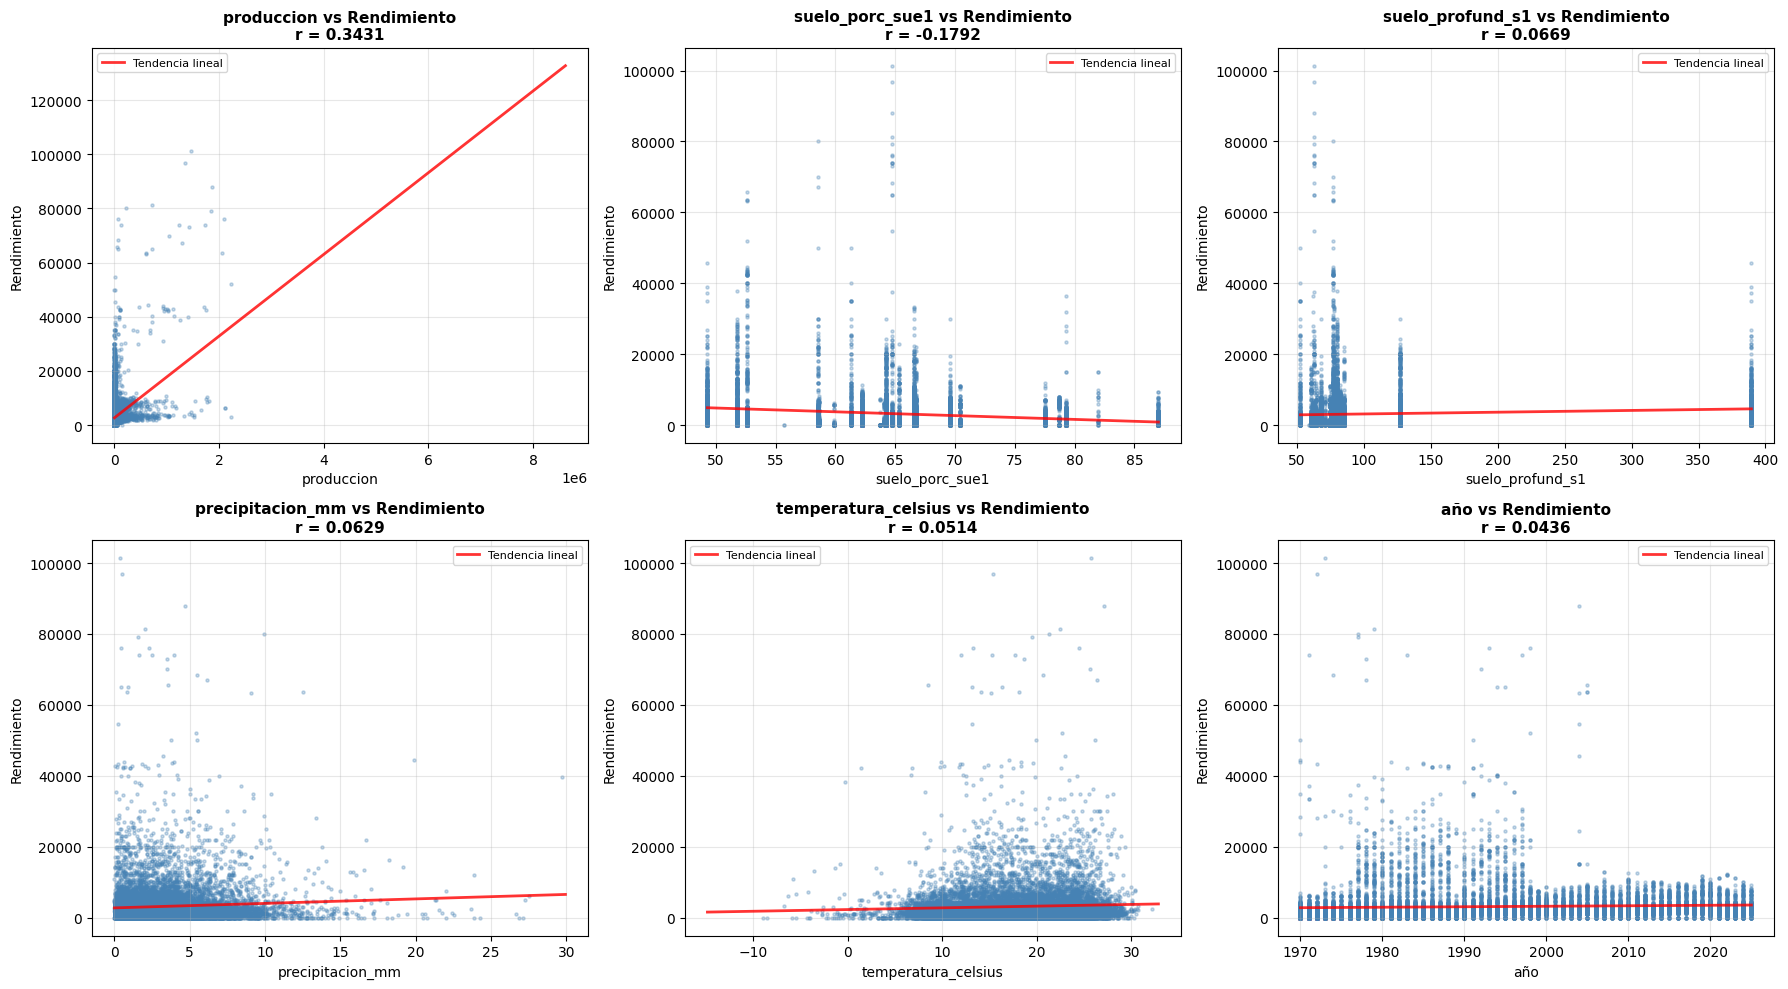

In [56]:
# Scatter plots de las features MÁS correlacionadas
print("="*80)
print("RELACIONES BIVARIADAS: TOP FEATURES CORRELACIONADAS")
print("="*80)

if 'rendimiento' in numerical_features:
    # Seleccionar top 6 features por correlación absoluta
    top_features = correlations.abs().nlargest(6)
    
    print(f"\nVisualizando las {len(top_features)} features más correlacionadas con rendimiento:\n")
    for feat in top_features.index:
        print(f"  - {feat}: r = {correlations[feat]:.4f}")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, feat in enumerate(top_features.index):
        # Filtrar datos válidos
        data_clean = full_data[[feat, 'rendimiento']].dropna()
        
        # Si hay muchos datos, tomar muestra
        if len(data_clean) > 15000:
            data_sample = data_clean.sample(n=15000, random_state=42)
        else:
            data_sample = data_clean
        
        # Scatter plot
        axes[idx].scatter(data_sample[feat], data_sample['rendimiento'], 
                         alpha=0.3, s=5, c='steelblue')
        
        # Línea de tendencia
        z = np.polyfit(data_clean[feat], data_clean['rendimiento'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data_clean[feat].min(), data_clean[feat].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r-", linewidth=2, alpha=0.8, label='Tendencia lineal')
        
        axes[idx].set_xlabel(feat, fontsize=10)
        axes[idx].set_ylabel('Rendimiento', fontsize=10)
        axes[idx].set_title(f'{feat} vs Rendimiento\nr = {correlations[feat]:.4f}', 
                           fontsize=11, fontweight='bold')
        axes[idx].grid(alpha=0.3)
        axes[idx].legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

### 💡 Interpretación de Correlaciones

**Escala de correlación de Pearson:**
- **|r| = 1.0**: Correlación perfecta
- **|r| ≥ 0.7**: Correlación muy fuerte
- **0.5 ≤ |r| < 0.7**: Correlación fuerte
- **0.3 ≤ |r| < 0.5**: Correlación moderada
- **0.1 ≤ |r| < 0.3**: Correlación débil
- **|r| < 0.1**: Correlación muy débil o inexistente

**Signo de la correlación:**
- **Positiva (+)**: Al aumentar la feature, aumenta el rendimiento
- **Negativa (-)**: Al aumentar la feature, disminuye el rendimiento

**Implicaciones para el modelo:**
- Features con correlación fuerte/muy fuerte son buenos predictores individuales
- Features con correlación débil pueden ser útiles en combinación con otras
- La correlación de Pearson solo mide relaciones **lineales**
- Features no correlacionadas linealmente pueden tener relaciones no lineales importantes

---

# Análisis Exploratorio de Datos (EDA)
## Dataset: Producción Agrícola Argentina con Variables Climáticas y Edáficas

---

## 1. Información General del Dataset

In [57]:
# Información básica del dataset
print("="*80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*80)

print(f"\nDimensiones: {full_data.shape[0]:,} filas × {full_data.shape[1]} columnas")
print(f"\nMemoria utilizada: {full_data.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

print(f"\n{'='*80}")
print("TIPOS DE DATOS")
print("="*80)
print(full_data.dtypes)

print(f"\n{'='*80}")
print("PRIMERAS FILAS")
print("="*80)
full_data.head()

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 1,441,934 filas × 15 columnas

Memoria utilizada: 532.50 MB

TIPOS DE DATOS
provincia_nombre        object
departamento_nombre     object
departamento_id         object
cultivo                 object
año                      int64
mes                      int64
rendimiento              int64
temperatura_celsius    float64
precipitacion_mm       float64
suelo_ind_prod         float64
suelo_porc_sue1        float64
suelo_profund_s1       float64
suelo_alcalin_s1        object
produccion               int64
sup_sembrada             int64
dtype: object

PRIMERAS FILAS


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion,sup_sembrada
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,1,3333,22.368317,5.617142,34.550898,66.545659,77.879491,No sodico,10,3
1,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,2,3333,23.294342,1.991272,34.550898,66.545659,77.879491,No sodico,10,3
2,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,3,3333,19.947906,6.193161,34.550898,66.545659,77.879491,No sodico,10,3
3,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,4,3333,18.099762,3.725052,34.550898,66.545659,77.879491,No sodico,10,3
4,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,5,3333,12.083649,0.638962,34.550898,66.545659,77.879491,No sodico,10,3


## 2. Análisis de Valores Faltantes

In [58]:
# Análisis de valores faltantes
missing = full_data.isnull().sum()
missing_percent = 100 * missing / len(full_data)

missing_df = pd.DataFrame({
    'Columna': missing.index,
    'Valores Faltantes': missing.values,
    'Porcentaje (%)': missing_percent.values
}).sort_values('Porcentaje (%)', ascending=False)

print("="*80)
print("VALORES FALTANTES POR COLUMNA")
print("="*80)
print(missing_df.to_string(index=False))

# Visualización
plt.figure(figsize=(12, 6))
missing_cols = missing_df[missing_df['Valores Faltantes'] > 0]
if len(missing_cols) > 0:
    plt.barh(missing_cols['Columna'], missing_cols['Porcentaje (%)'])
    plt.xlabel('Porcentaje de Valores Faltantes (%)')
    plt.title('Valores Faltantes por Columna')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

VALORES FALTANTES POR COLUMNA
            Columna  Valores Faltantes  Porcentaje (%)
   provincia_nombre                  0             0.0
departamento_nombre                  0             0.0
    departamento_id                  0             0.0
            cultivo                  0             0.0
                año                  0             0.0
                mes                  0             0.0
        rendimiento                  0             0.0
temperatura_celsius                  0             0.0
   precipitacion_mm                  0             0.0
     suelo_ind_prod                  0             0.0
    suelo_porc_sue1                  0             0.0
   suelo_profund_s1                  0             0.0
   suelo_alcalin_s1                  0             0.0
         produccion                  0             0.0
       sup_sembrada                  0             0.0

✅ No hay valores faltantes en el dataset


<Figure size 1200x600 with 0 Axes>

## 3. Análisis de Variables Numéricas

In [59]:
# Estadísticas descriptivas de variables numéricas
print("="*80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)

desc = full_data[numerical_features].describe()
print(desc.T.to_string())

# Estadísticas adicionales
print(f"\n{'='*80}")
print("ESTADÍSTICAS ADICIONALES")
print("="*80)

additional_stats = pd.DataFrame({
    'Mediana': full_data[numerical_features].median(),
    'Moda': full_data[numerical_features].mode().iloc[0],
})

print(additional_stats.to_string())

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
                         count          mean            std          min          25%          50%           75%           max
año                  1441934.0   1994.303760      16.960719  1970.000000  1979.000000  1991.000000   2010.000000  2.025000e+03
mes                  1441934.0      6.484028       3.445842     1.000000     3.000000     6.000000      9.000000  1.200000e+01
rendimiento          1441934.0   3126.652870    5319.137151     0.000000   900.000000  1800.000000   3307.000000  1.324050e+05
temperatura_celsius  1441934.0     17.719220       5.677643   -14.825775    13.404199    18.102197     22.311920  3.284927e+01
precipitacion_mm     1441934.0      3.009760       2.642622     0.000000     1.108170     2.368927      4.144669  2.993011e+01
suelo_ind_prod       1441934.0     29.299887       7.962957     9.129310    21.090000    34.550898     34.550898  4.825735e+01
suelo_porc_sue1      1441934.0     65.846856       8.890645    

DISTRIBUCIONES DE VARIABLES NUMÉRICAS


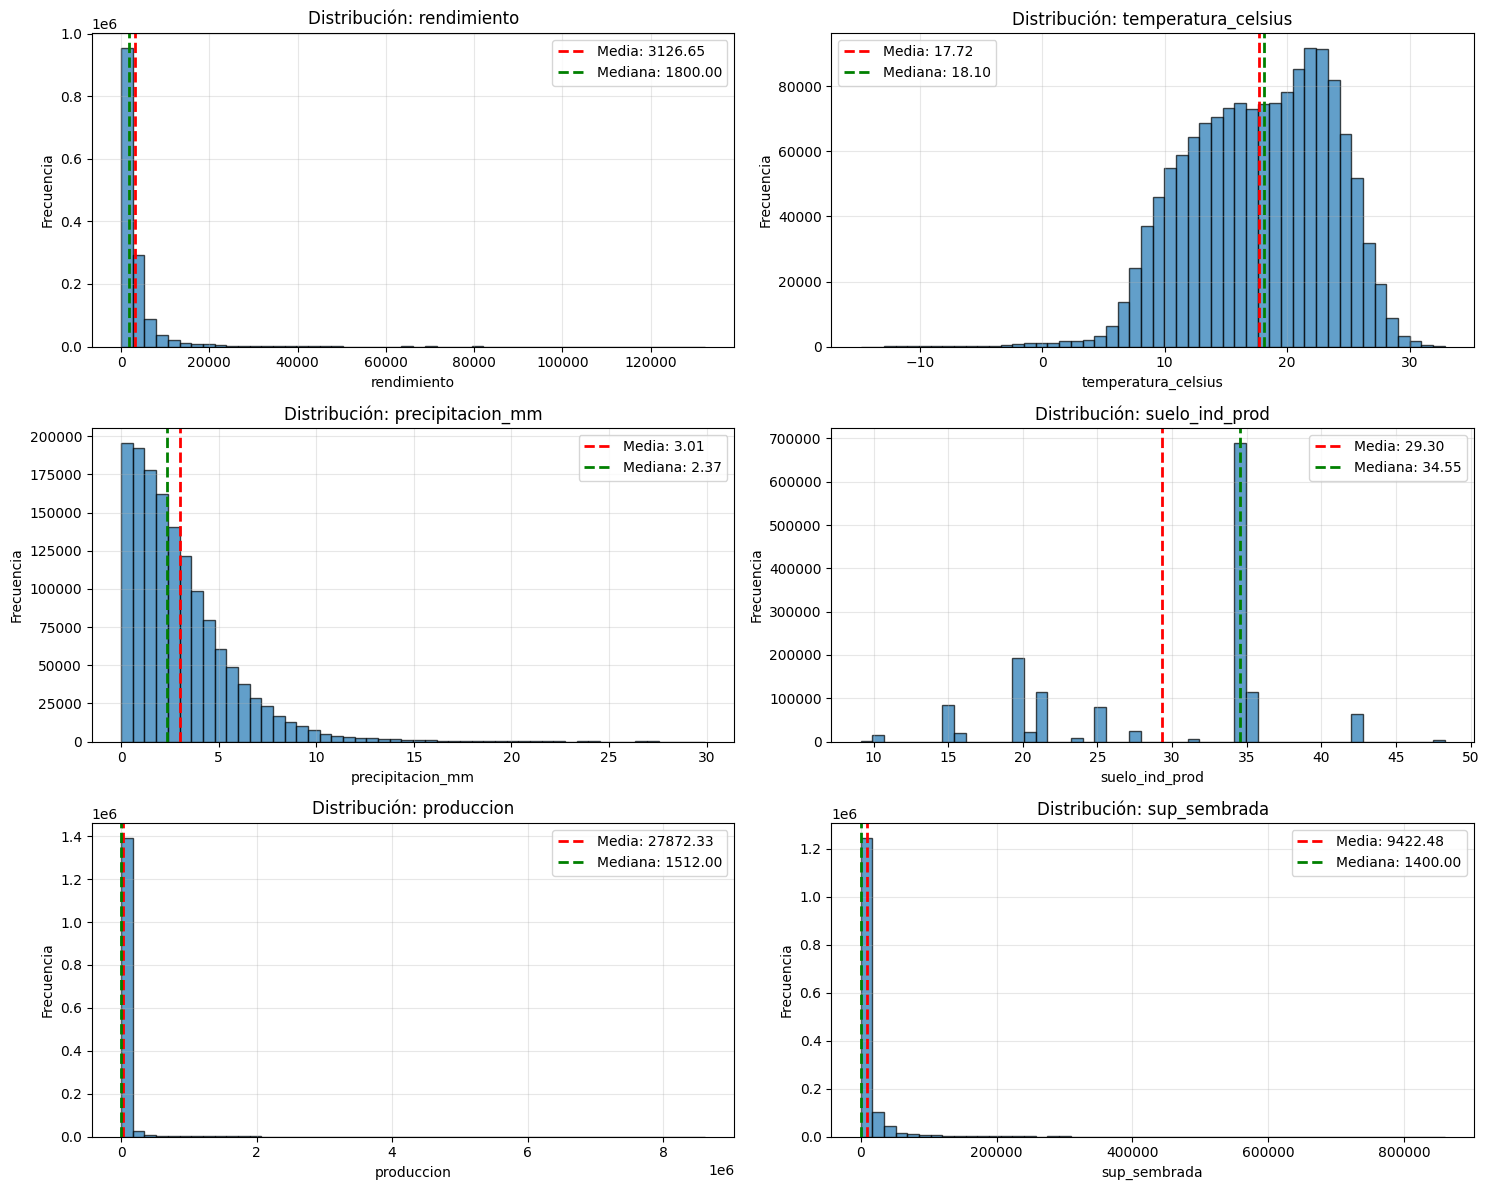

In [60]:
# Distribuciones de variables numéricas
print("="*80)
print("DISTRIBUCIONES DE VARIABLES NUMÉRICAS")
print("="*80)

# Seleccionar variables clave para visualización
vars_clave = ['rendimiento', 'temperatura_celsius', 'precipitacion_mm', 
              'suelo_ind_prod', 'produccion', 'sup_sembrada']

# Filtrar solo las que existen
vars_plot = [v for v in vars_clave if v in numerical_features]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, var in enumerate(vars_plot):
    if idx < len(axes):
        # Filtrar valores no nulos
        data_clean = full_data[var].dropna()
        
        axes[idx].hist(data_clean, bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribución: {var}')
        axes[idx].set_xlabel(var)
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(alpha=0.3)
        
        # Agregar estadísticas
        mean_val = data_clean.mean()
        median_val = data_clean.median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        axes[idx].legend()

plt.tight_layout()
plt.show()

DETECCIÓN DE OUTLIERS - BOXPLOTS


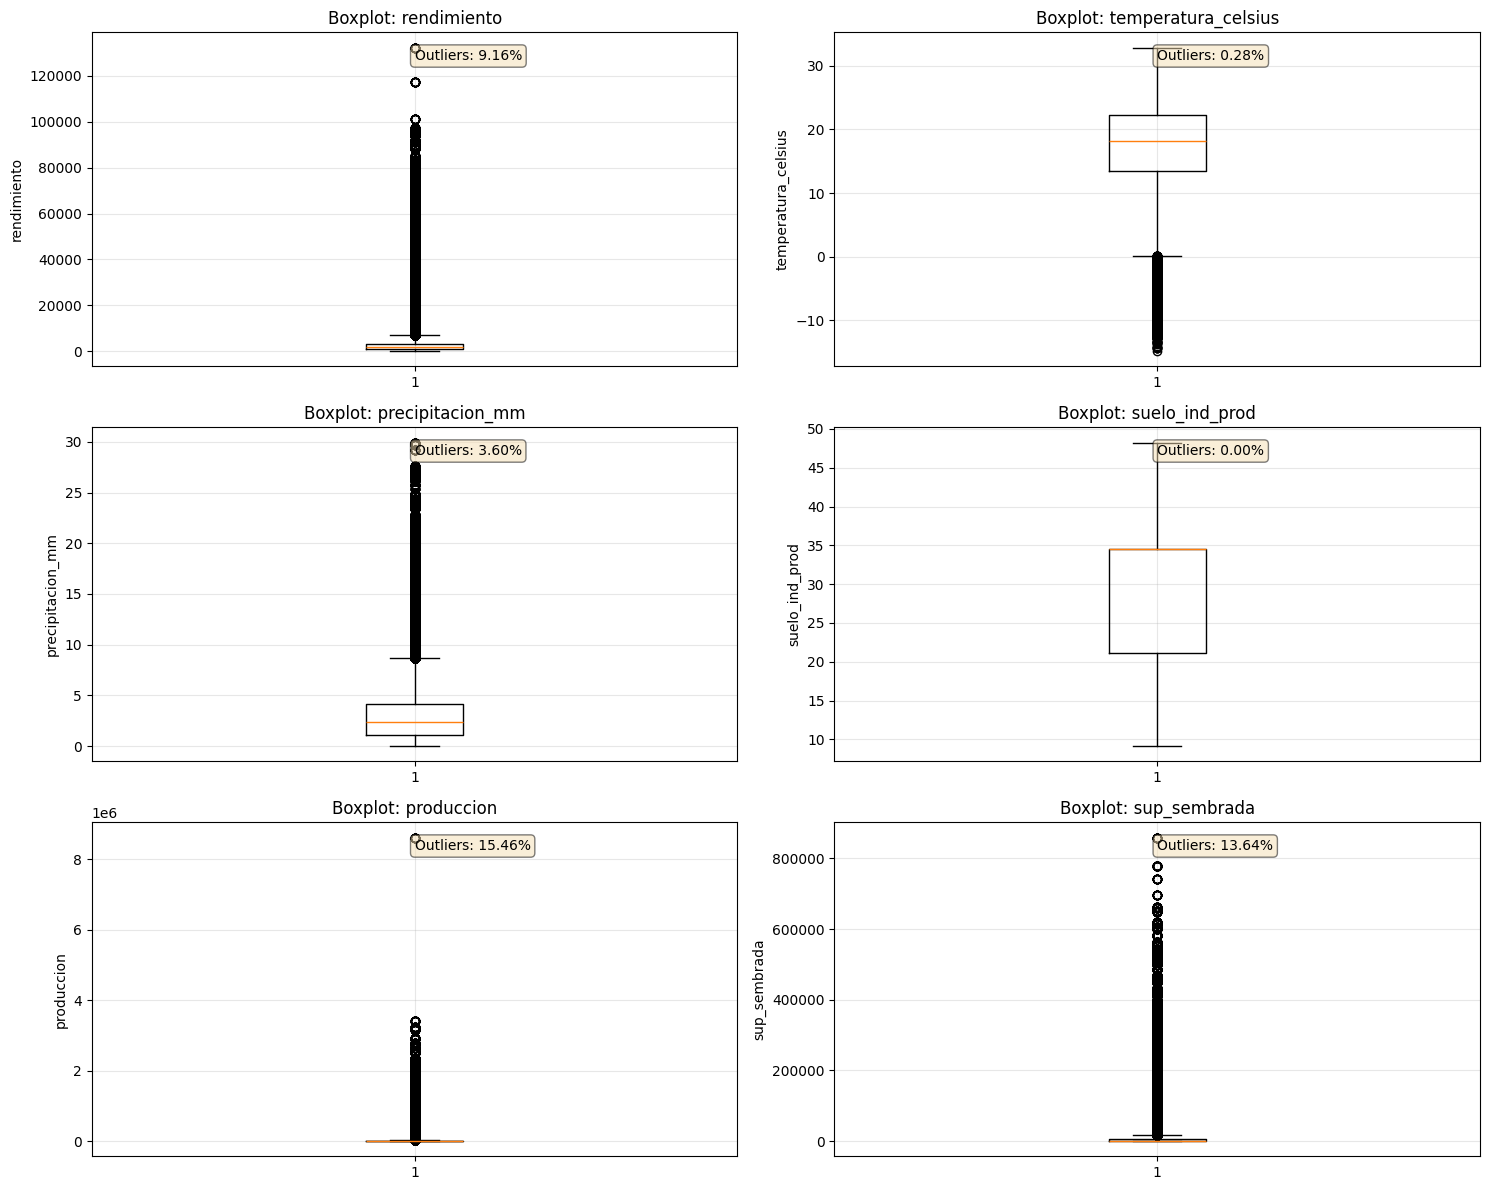

In [61]:
# Boxplots para detectar outliers
print("="*80)
print("DETECCIÓN DE OUTLIERS - BOXPLOTS")
print("="*80)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, var in enumerate(vars_plot):
    if idx < len(axes):
        # Filtrar valores no nulos
        data_clean = full_data[var].dropna()
        
        axes[idx].boxplot(data_clean, vert=True)
        axes[idx].set_title(f'Boxplot: {var}')
        axes[idx].set_ylabel(var)
        axes[idx].grid(alpha=0.3)
        
        # Calcular outliers con IQR
        Q1 = data_clean.quantile(0.25)
        Q3 = data_clean.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data_clean[(data_clean < lower_bound) | (data_clean > upper_bound)]
        outlier_pct = 100 * len(outliers) / len(data_clean)
        
        axes[idx].text(0.5, 0.95, f'Outliers: {outlier_pct:.2f}%', 
                      transform=axes[idx].transAxes, 
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 4. Análisis de Variables Categóricas

In [62]:
# Análisis de variables categóricas
print("="*80)
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*80)

for col in categorical_features:
    print(f"\n{'='*80}")
    print(f"Variable: {col}")
    print("="*80)
    
    n_unique = full_data[col].nunique()
    print(f"Valores únicos: {n_unique}")
    
    if n_unique <= 50:  # Solo mostrar top si no son demasiados
        value_counts = full_data[col].value_counts()
        print(f"\nTop 10 valores más frecuentes:")
        print(value_counts.head(10).to_string())
    else:
        print(f"\nPrimeros 10 valores únicos:")
        print(full_data[col].unique()[:10])

ANÁLISIS DE VARIABLES CATEGÓRICAS

Variable: provincia_nombre
Valores únicos: 23

Top 10 valores más frecuentes:
provincia_nombre
Buenos Aires           488806
Santa Fe               114258
Cordoba                106600
Corrientes              85464
La Pampa                84720
Chaco                   84378
Entre Rios              79658
Misiones                77286
Santiago Del Estero     63866
Salta                   48722

Variable: departamento_nombre
Valores únicos: 405

Primeros 10 valores únicos:
['25 DE MAYO' 'ADOLFO GONZALES CHAVES' 'ALBERTI' 'ALMIRANTE BROWN'
 'ARRECIFES' 'AYACUCHO' 'AZUL' 'BAHIA BLANCA' 'BALCARCE' 'BARADERO']

Variable: departamento_id
Valores únicos: 483

Primeros 10 valores únicos:
['BUENOS AIRES - 25 DE MAYO' 'BUENOS AIRES - ADOLFO GONZALES CHAVES'
 'BUENOS AIRES - ALBERTI' 'BUENOS AIRES - ALMIRANTE BROWN'
 'BUENOS AIRES - ARRECIFES' 'BUENOS AIRES - AYACUCHO'
 'BUENOS AIRES - AZUL' 'BUENOS AIRES - BAHIA BLANCA'
 'BUENOS AIRES - BALCARCE' 'BUENOS AIRES - 

DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS CLAVE


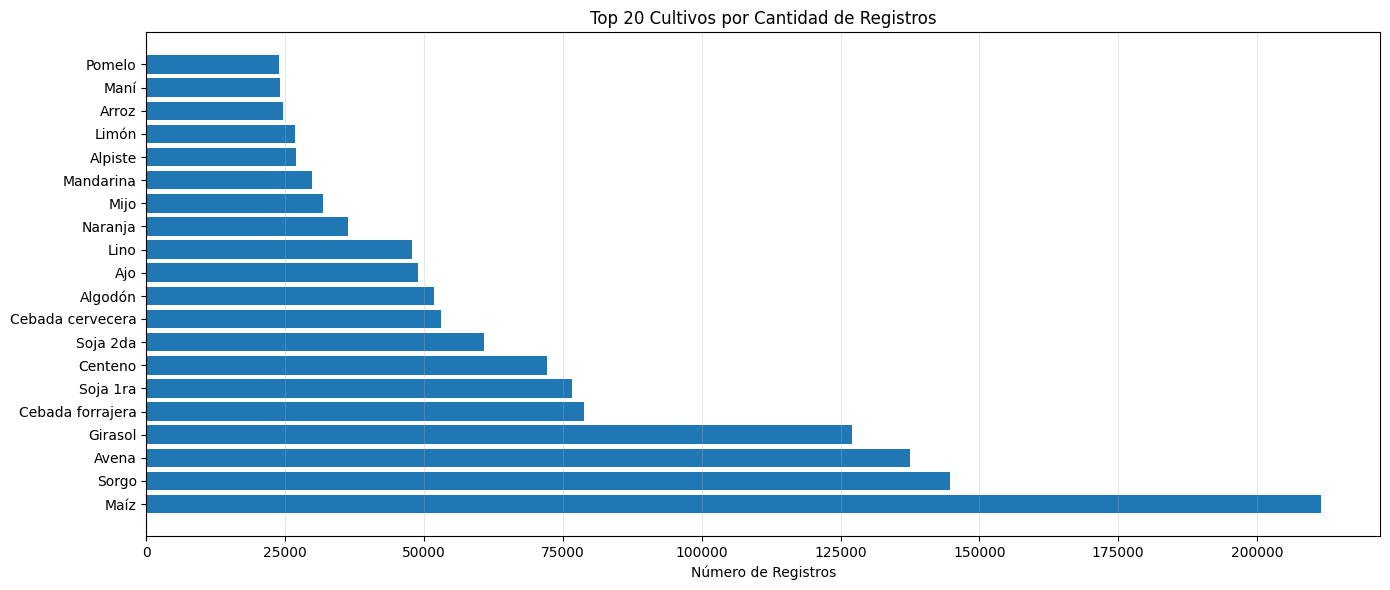

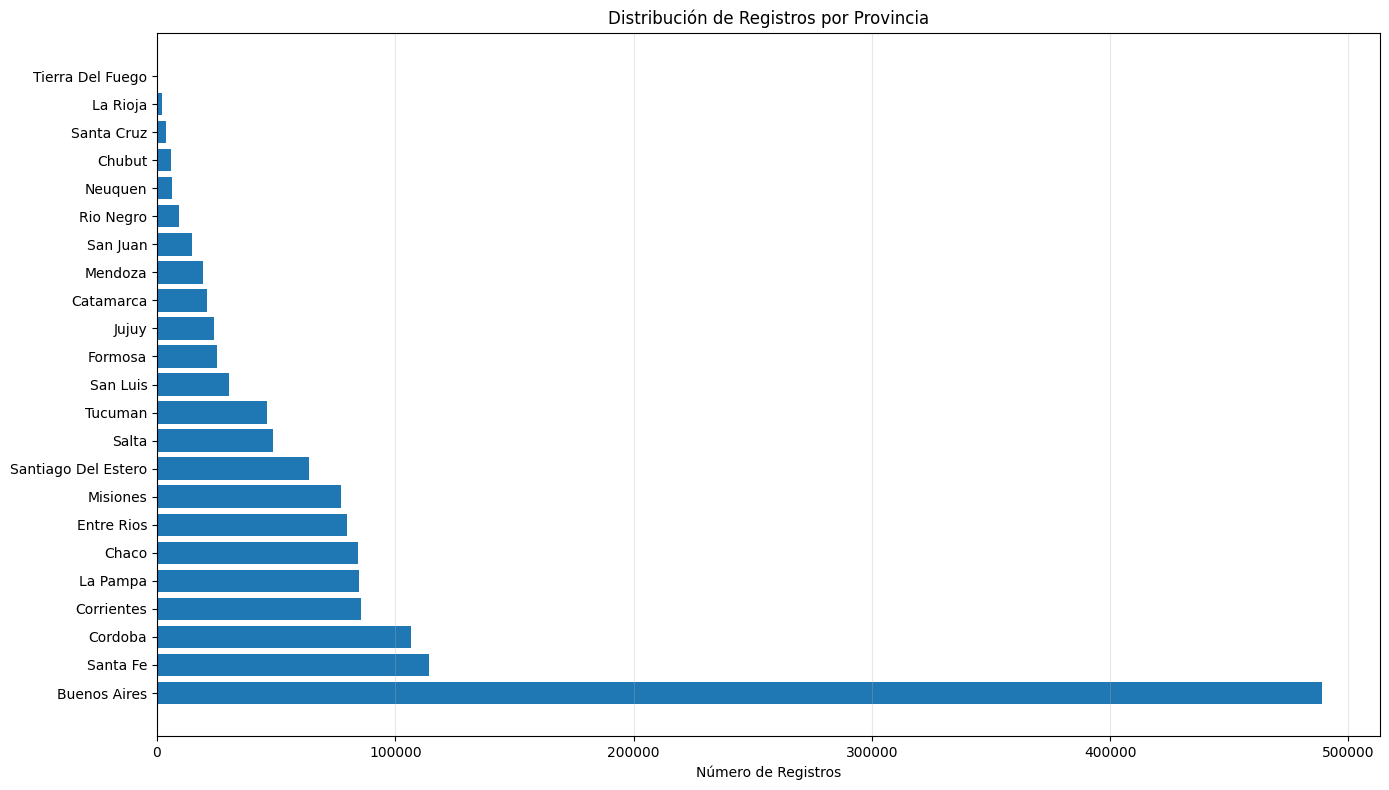

In [63]:
# Visualización de variables categóricas clave
print("="*80)
print("DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS CLAVE")
print("="*80)

# Cultivos
if 'cultivo' in categorical_features:
    plt.figure(figsize=(14, 6))
    
    cultivo_counts = full_data['cultivo'].value_counts().head(20)
    
    plt.barh(range(len(cultivo_counts)), cultivo_counts.values)
    plt.yticks(range(len(cultivo_counts)), cultivo_counts.index)
    plt.xlabel('Número de Registros')
    plt.title('Top 20 Cultivos por Cantidad de Registros')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Provincias
if 'provincia_nombre' in categorical_features:
    plt.figure(figsize=(14, 8))
    
    provincia_counts = full_data['provincia_nombre'].value_counts()
    
    plt.barh(range(len(provincia_counts)), provincia_counts.values)
    plt.yticks(range(len(provincia_counts)), provincia_counts.index)
    plt.xlabel('Número de Registros')
    plt.title('Distribución de Registros por Provincia')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Análisis Temporal

In [64]:
# Análisis temporal
print("="*80)
print("ANÁLISIS TEMPORAL")
print("="*80)

if 'año' in full_data.columns:
    print(f"\nRango temporal:")
    print(f"  Año mínimo: {full_data['año'].min()}")
    print(f"  Año máximo: {full_data['año'].max()}")
    print(f"  Años totales: {full_data['año'].max() - full_data['año'].min() + 1}")
    
    print(f"\nRegistros por año:")
    year_counts = full_data['año'].value_counts().sort_index()
    print(year_counts.describe().to_string())

if 'mes' in full_data.columns:
    print(f"\nDistribución por mes:")
    mes_counts = full_data['mes'].value_counts().sort_index()
    print(mes_counts.to_string())

ANÁLISIS TEMPORAL

Rango temporal:
  Año mínimo: 1970
  Año máximo: 2025
  Años totales: 56

Registros por año:
count       56.000000
mean     25748.821429
std       7331.326575
min      14820.000000
25%      20334.000000
50%      22146.000000
75%      33984.000000
max      37956.000000

Distribución por mes:
mes
1     120545
2     120545
3     120545
4     120545
5     120545
6     120545
7     120545
8     120545
9     120545
10    120545
11    118242
12    118242


EVOLUCIÓN TEMPORAL DE VARIABLES CLAVE


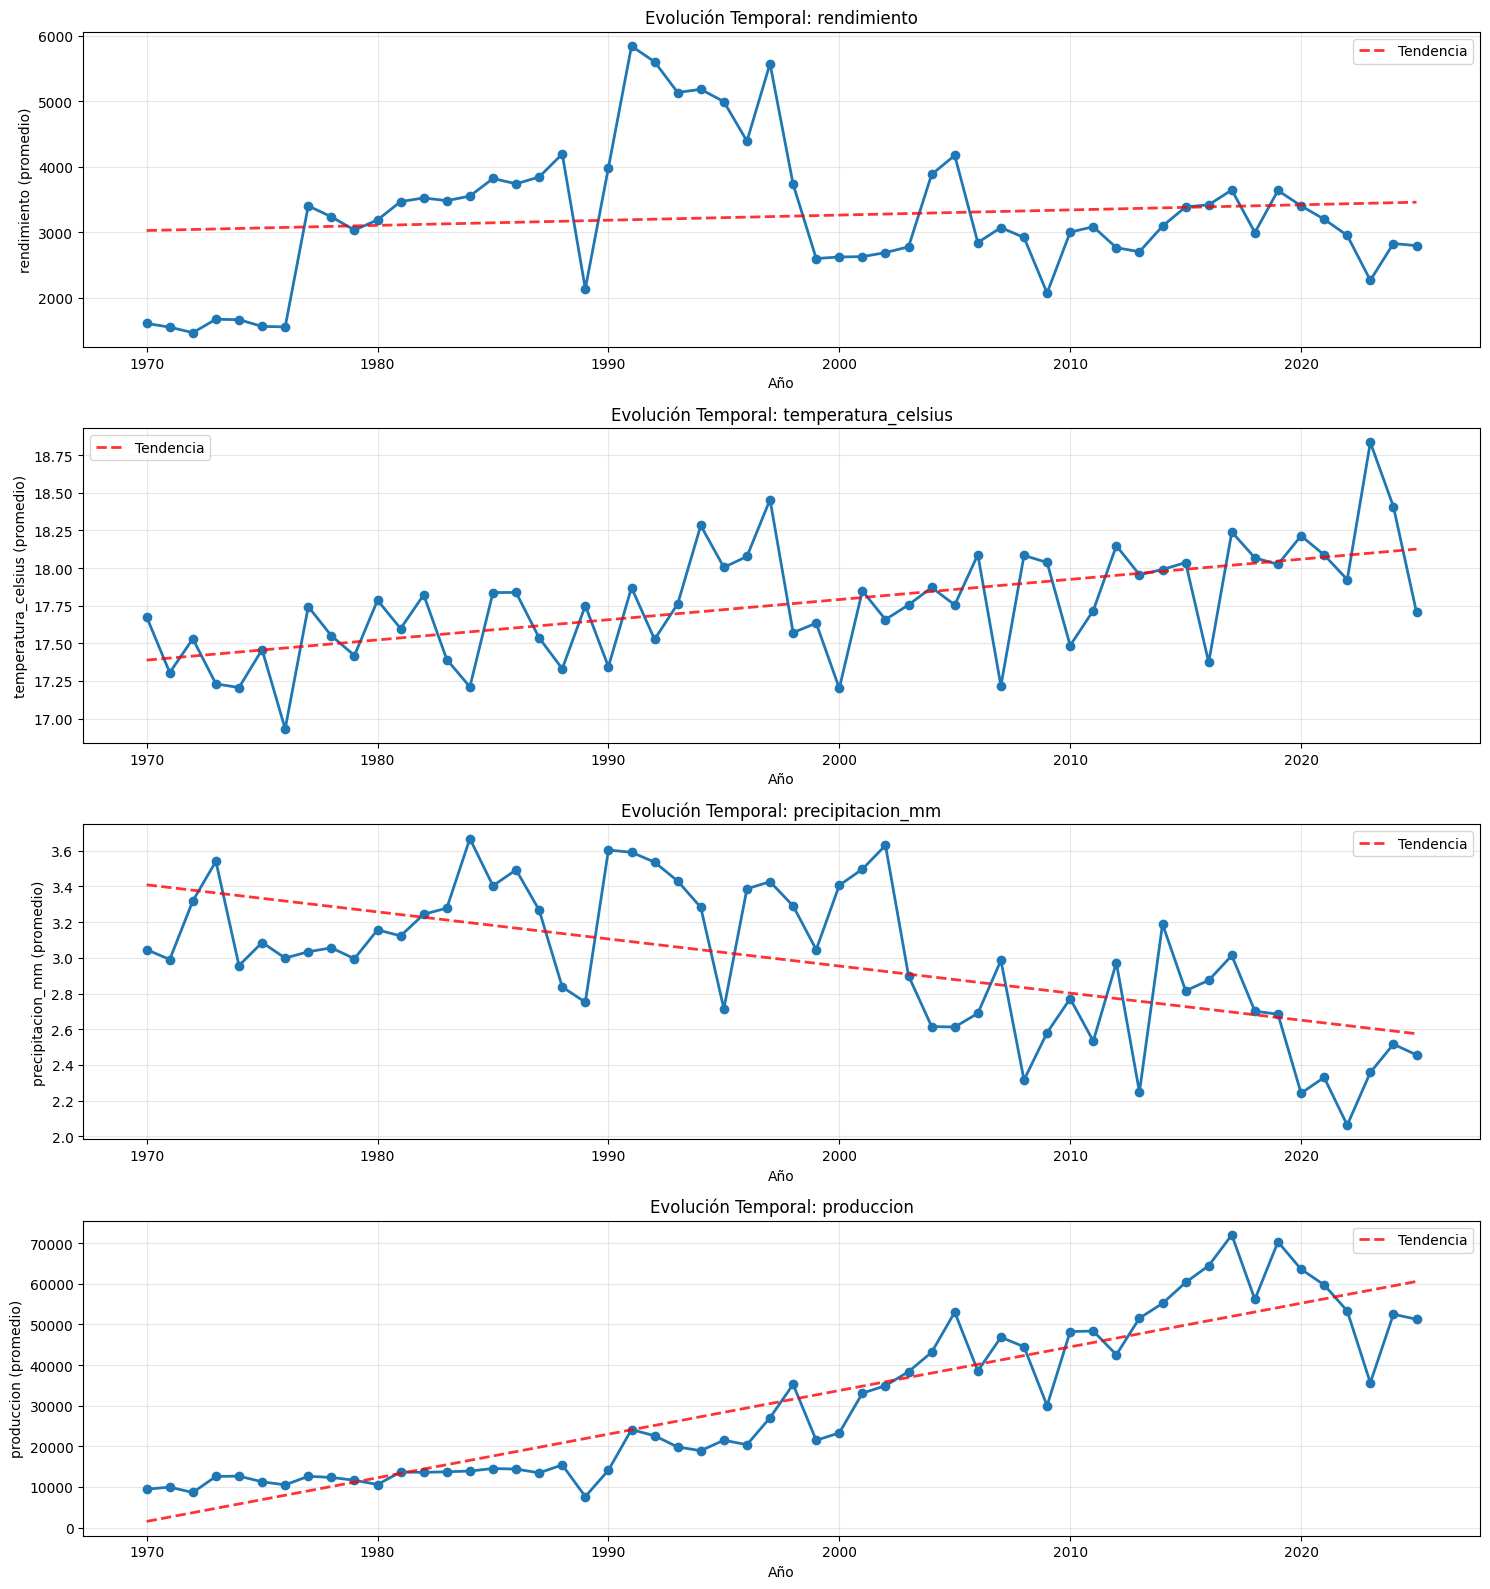

In [65]:
# Evolución temporal de variables clave
print("="*80)
print("EVOLUCIÓN TEMPORAL DE VARIABLES CLAVE")
print("="*80)

if 'año' in full_data.columns:
    # Preparar datos agregados por año
    vars_to_plot = ['rendimiento', 'temperatura_celsius', 'precipitacion_mm', 'produccion']
    vars_available = [v for v in vars_to_plot if v in numerical_features]
    
    fig, axes = plt.subplots(len(vars_available), 1, figsize=(15, 4*len(vars_available)))
    
    if len(vars_available) == 1:
        axes = [axes]
    
    for idx, var in enumerate(vars_available):
        # Calcular promedio por año
        yearly_avg = full_data.groupby('año')[var].mean()
        
        axes[idx].plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2)
        axes[idx].set_xlabel('Año')
        axes[idx].set_ylabel(f'{var} (promedio)')
        axes[idx].set_title(f'Evolución Temporal: {var}')
        axes[idx].grid(alpha=0.3)
        
        # Agregar línea de tendencia
        z = np.polyfit(yearly_avg.index, yearly_avg.values, 1)
        p = np.poly1d(z)
        axes[idx].plot(yearly_avg.index, p(yearly_avg.index), "r--", alpha=0.8, linewidth=2, label='Tendencia')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()

ANÁLISIS ESTACIONAL (POR MES)


/var/folders/kh/zlskj21d0z3d83mthqvlj3z40000gn/T/ipykernel_16641/3588700576.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(monthly_data, labels=range(1, 13))


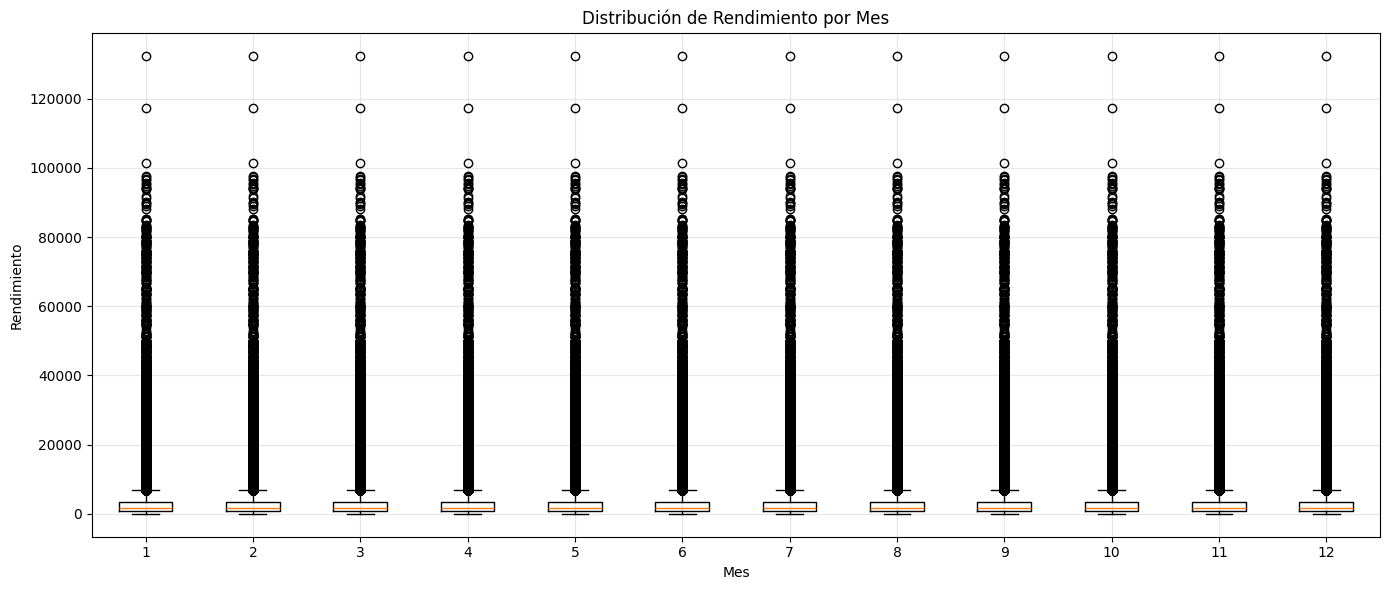


Promedio de rendimiento por mes:
mes
1     3125.588958
2     3125.588958
3     3125.588958
4     3125.588958
5     3125.588958
6     3125.588958
7     3125.588958
8     3125.588958
9     3125.588958
10    3125.588958
11    3132.076039
12    3132.076039


In [66]:
# Análisis estacional (por mes)
print("="*80)
print("ANÁLISIS ESTACIONAL (POR MES)")
print("="*80)

if 'mes' in full_data.columns and 'rendimiento' in full_data.columns:
    # Boxplot de rendimiento por mes
    plt.figure(figsize=(14, 6))
    
    data_clean = full_data[full_data['rendimiento'].notna()]
    
    monthly_data = [data_clean[data_clean['mes'] == m]['rendimiento'].values for m in range(1, 13)]
    
    plt.boxplot(monthly_data, labels=range(1, 13))
    plt.xlabel('Mes')
    plt.ylabel('Rendimiento')
    plt.title('Distribución de Rendimiento por Mes')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Estadísticas por mes
    print("\nPromedio de rendimiento por mes:")
    monthly_avg = full_data.groupby('mes')['rendimiento'].mean().sort_index()
    print(monthly_avg.to_string())

## 6. Análisis de Correlaciones

MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS

Matriz de correlación:
                          año       mes  rendimiento  temperatura_celsius  precipitacion_mm  suelo_ind_prod  suelo_porc_sue1  suelo_profund_s1  produccion  sup_sembrada
año                  1.000000 -0.008389     0.043636             0.041304         -0.090966        0.105820         0.101958         -0.055987    0.143921      0.179574
mes                 -0.008389  1.000000     0.000291            -0.133920         -0.066104       -0.001247        -0.000352          0.000844   -0.000896     -0.001011
rendimiento          0.043636  0.000291     1.000000             0.051436          0.062912       -0.015517        -0.179211          0.066852    0.343133      0.017863
temperatura_celsius  0.041304 -0.133920     0.051436             1.000000          0.368761       -0.043732        -0.077561          0.106324    0.007213      0.001616
precipitacion_mm    -0.090966 -0.066104     0.062912             0.368761          1.00

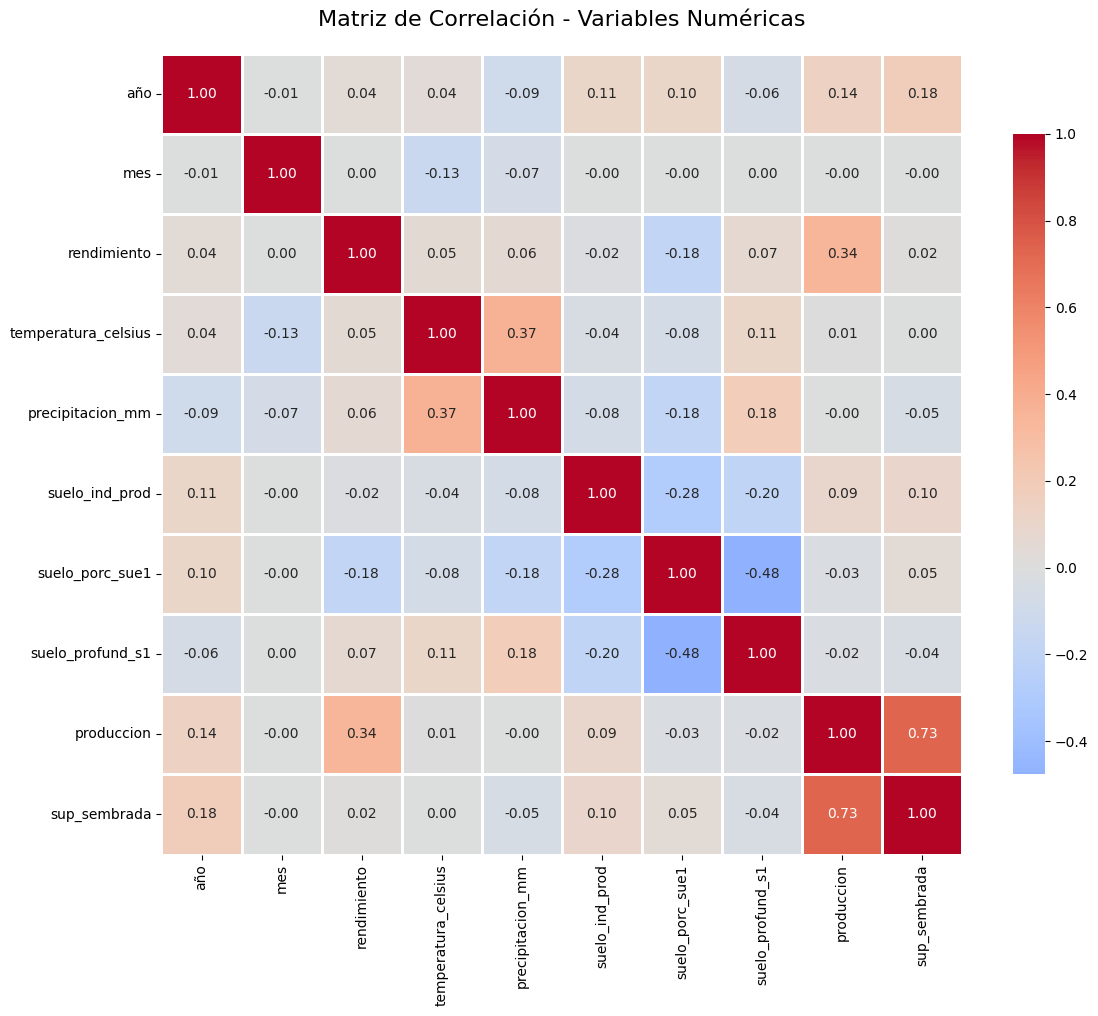

In [67]:
# Matriz de correlación
print("="*80)
print("MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS")
print("="*80)

# Calcular correlación solo con datos completos
corr_matrix = full_data[numerical_features].corr()

print("\nMatriz de correlación:")
print(corr_matrix.to_string())

# Heatmap de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

CORRELACIONES CON RENDIMIENTO (Variable Objetivo)
rendimiento            1.000000
produccion             0.343133
suelo_profund_s1       0.066852
precipitacion_mm       0.062912
temperatura_celsius    0.051436
año                    0.043636
sup_sembrada           0.017863
mes                    0.000291
suelo_ind_prod        -0.015517
suelo_porc_sue1       -0.179211


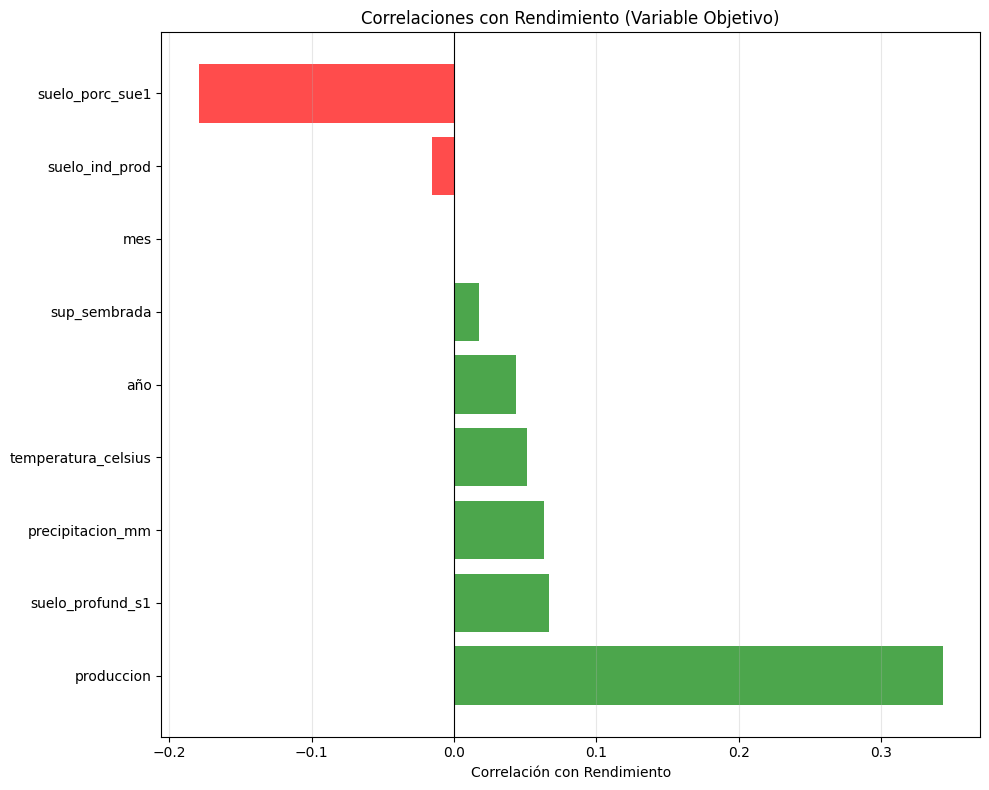

In [68]:
# Correlaciones con la variable objetivo (rendimiento)
print("="*80)
print("CORRELACIONES CON RENDIMIENTO (Variable Objetivo)")
print("="*80)

if 'rendimiento' in numerical_features:
    correlations = corr_matrix['rendimiento'].sort_values(ascending=False)
    print(correlations.to_string())
    
    # Visualización
    plt.figure(figsize=(10, 8))
    correlations_plot = correlations[correlations.index != 'rendimiento']
    
    colors = ['green' if x > 0 else 'red' for x in correlations_plot.values]
    plt.barh(range(len(correlations_plot)), correlations_plot.values, color=colors, alpha=0.7)
    plt.yticks(range(len(correlations_plot)), correlations_plot.index)
    plt.xlabel('Correlación con Rendimiento')
    plt.title('Correlaciones con Rendimiento (Variable Objetivo)')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

RELACIONES BIVARIADAS CON RENDIMIENTO


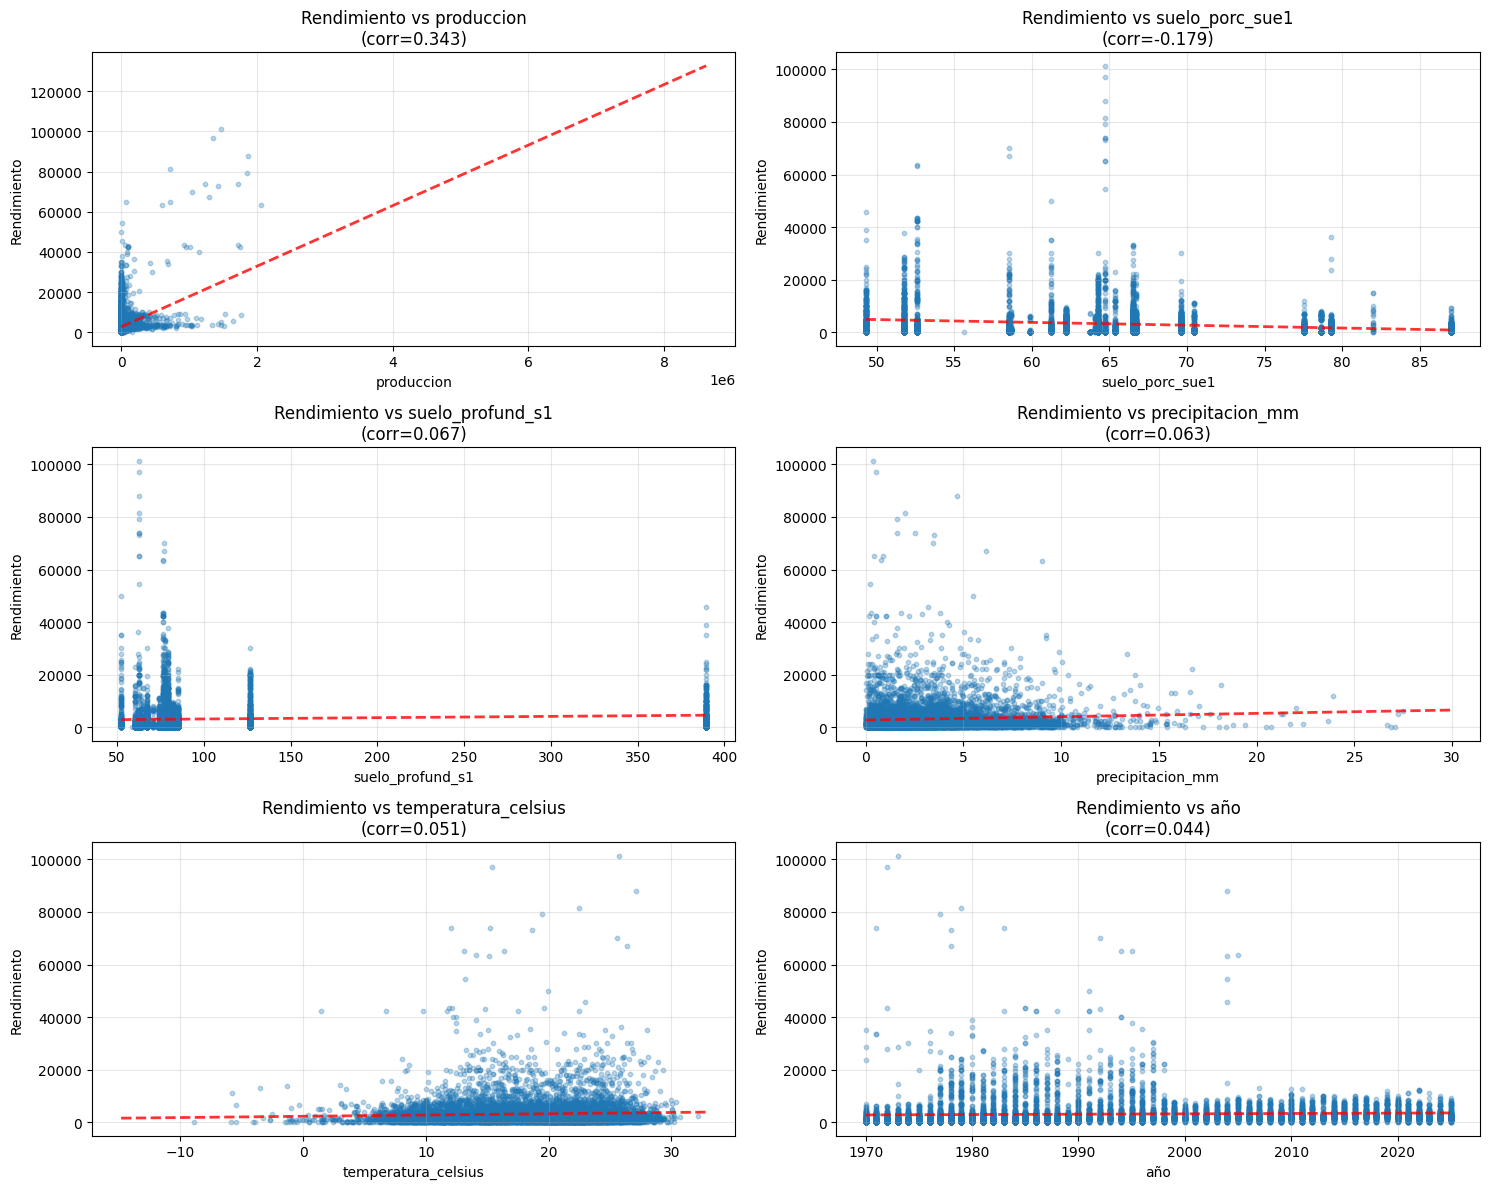

In [69]:
# Scatter plots de variables más correlacionadas con rendimiento
print("="*80)
print("RELACIONES BIVARIADAS CON RENDIMIENTO")
print("="*80)

if 'rendimiento' in numerical_features:
    # Seleccionar las 6 variables más correlacionadas (excluyendo rendimiento)
    top_corr = correlations[correlations.index != 'rendimiento'].abs().nlargest(6)
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, var in enumerate(top_corr.index):
        if idx < len(axes):
            # Filtrar datos válidos
            data_clean = full_data[[var, 'rendimiento']].dropna()
            
            # Scatter plot con muestra si hay muchos datos
            if len(data_clean) > 10000:
                data_sample = data_clean.sample(n=10000, random_state=42)
            else:
                data_sample = data_clean
            
            axes[idx].scatter(data_sample[var], data_sample['rendimiento'], 
                            alpha=0.3, s=10)
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('Rendimiento')
            axes[idx].set_title(f'Rendimiento vs {var}\n(corr={correlations[var]:.3f})')
            axes[idx].grid(alpha=0.3)
            
            # Línea de tendencia
            z = np.polyfit(data_clean[var], data_clean['rendimiento'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(data_clean[var].min(), data_clean[var].max(), 100)
            axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)
    
    plt.tight_layout()
    plt.show()

## 7. Análisis por Cultivo

In [70]:
# Estadísticas por cultivo
print("="*80)
print("ANÁLISIS POR CULTIVO")
print("="*80)

if 'cultivo' in categorical_features and 'rendimiento' in numerical_features:
    # Top cultivos por número de registros
    top_cultivos = full_data['cultivo'].value_counts().head(15)
    print("\nTop 15 cultivos por cantidad de registros:")
    print(top_cultivos.to_string())
    
    # Estadísticas de rendimiento por cultivo
    print("\n" + "="*80)
    print("ESTADÍSTICAS DE RENDIMIENTO POR CULTIVO")
    print("="*80)
    
    rendimiento_por_cultivo = full_data.groupby('cultivo')['rendimiento'].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('median', 'median'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max')
    ]).sort_values('mean', ascending=False)
    
    print("\nTop 15 cultivos por rendimiento promedio:")
    print(rendimiento_por_cultivo.head(15).to_string())

ANÁLISIS POR CULTIVO

Top 15 cultivos por cantidad de registros:
cultivo
Maíz                211574
Sorgo               144640
Avena               137508
Girasol             127130
Cebada forrajera     78840
Soja 1ra             76590
Centeno              72046
Soja 2da             60744
Cebada cervecera     53100
Algodón              51750
Ajo                  48960
Lino                 47794
Naranja              36288
Mijo                 31740
Mandarina            29748

ESTADÍSTICAS DE RENDIMIENTO POR CULTIVO

Top 15 cultivos por rendimiento promedio:
                 count          mean   median           std  min     max
cultivo                                                                 
Caña de azúcar   15492  33947.151820  30000.0  22524.718292    0  132405
Banana            5172  11690.482599  10000.0  10456.275724    0   37500
Limón            26712  10700.039982  10434.0   9306.462462    0   35315
Pomelo           23916   9464.430005   9000.0   8445.666616    0   49500


DISTRIBUCIÓN DE RENDIMIENTO POR CULTIVO


<Figure size 1400x800 with 0 Axes>

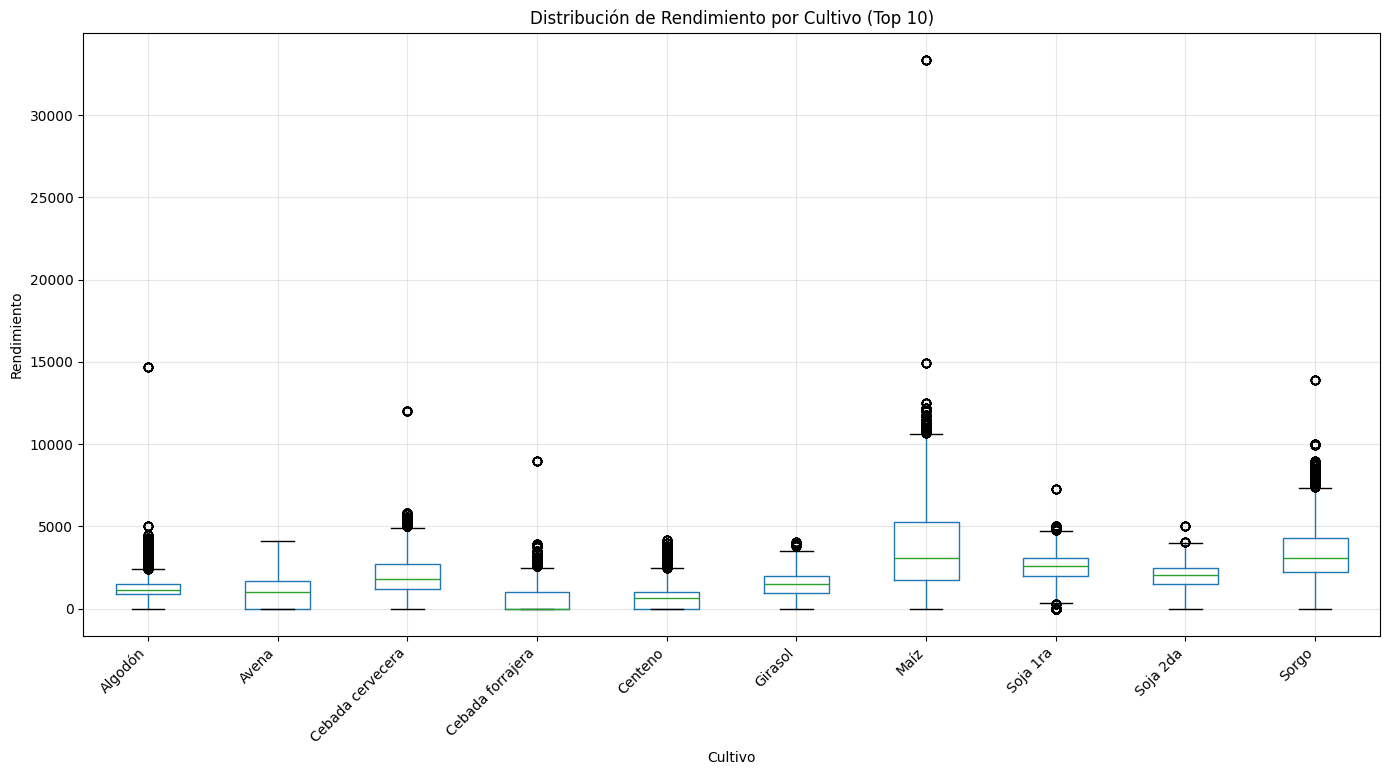

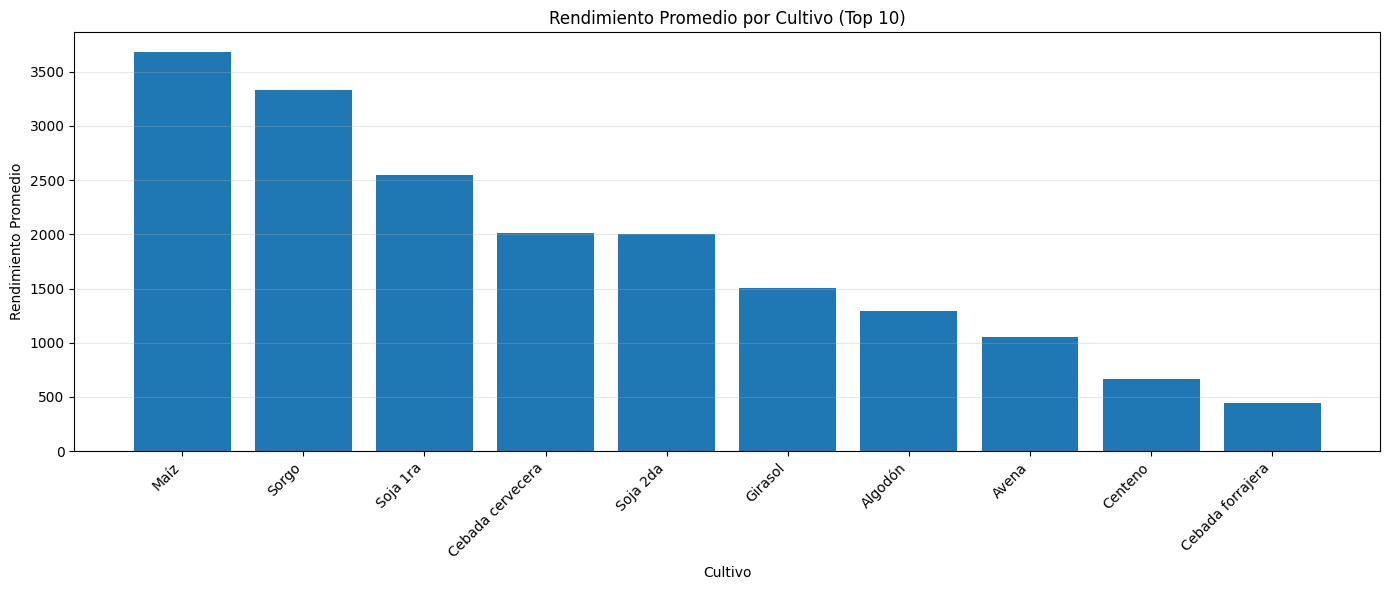

In [71]:
# Visualización de rendimiento por cultivo
print("="*80)
print("DISTRIBUCIÓN DE RENDIMIENTO POR CULTIVO")
print("="*80)

if 'cultivo' in categorical_features and 'rendimiento' in numerical_features:
    # Seleccionar top 10 cultivos por cantidad de registros
    top_10_cultivos = full_data['cultivo'].value_counts().head(10).index
    
    # Filtrar datos
    data_top_cultivos = full_data[full_data['cultivo'].isin(top_10_cultivos)].copy()
    
    # Boxplot
    plt.figure(figsize=(14, 8))
    data_top_cultivos.boxplot(column='rendimiento', by='cultivo', figsize=(14, 8))
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Cultivo')
    plt.ylabel('Rendimiento')
    plt.title('Distribución de Rendimiento por Cultivo (Top 10)')
    plt.suptitle('')  # Remover título automático
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Barplot de rendimiento promedio
    plt.figure(figsize=(14, 6))
    avg_rendimiento = data_top_cultivos.groupby('cultivo')['rendimiento'].mean().sort_values(ascending=False)
    plt.bar(range(len(avg_rendimiento)), avg_rendimiento.values)
    plt.xticks(range(len(avg_rendimiento)), avg_rendimiento.index, rotation=45, ha='right')
    plt.xlabel('Cultivo')
    plt.ylabel('Rendimiento Promedio')
    plt.title('Rendimiento Promedio por Cultivo (Top 10)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

EVOLUCIÓN TEMPORAL DE RENDIMIENTO POR CULTIVO


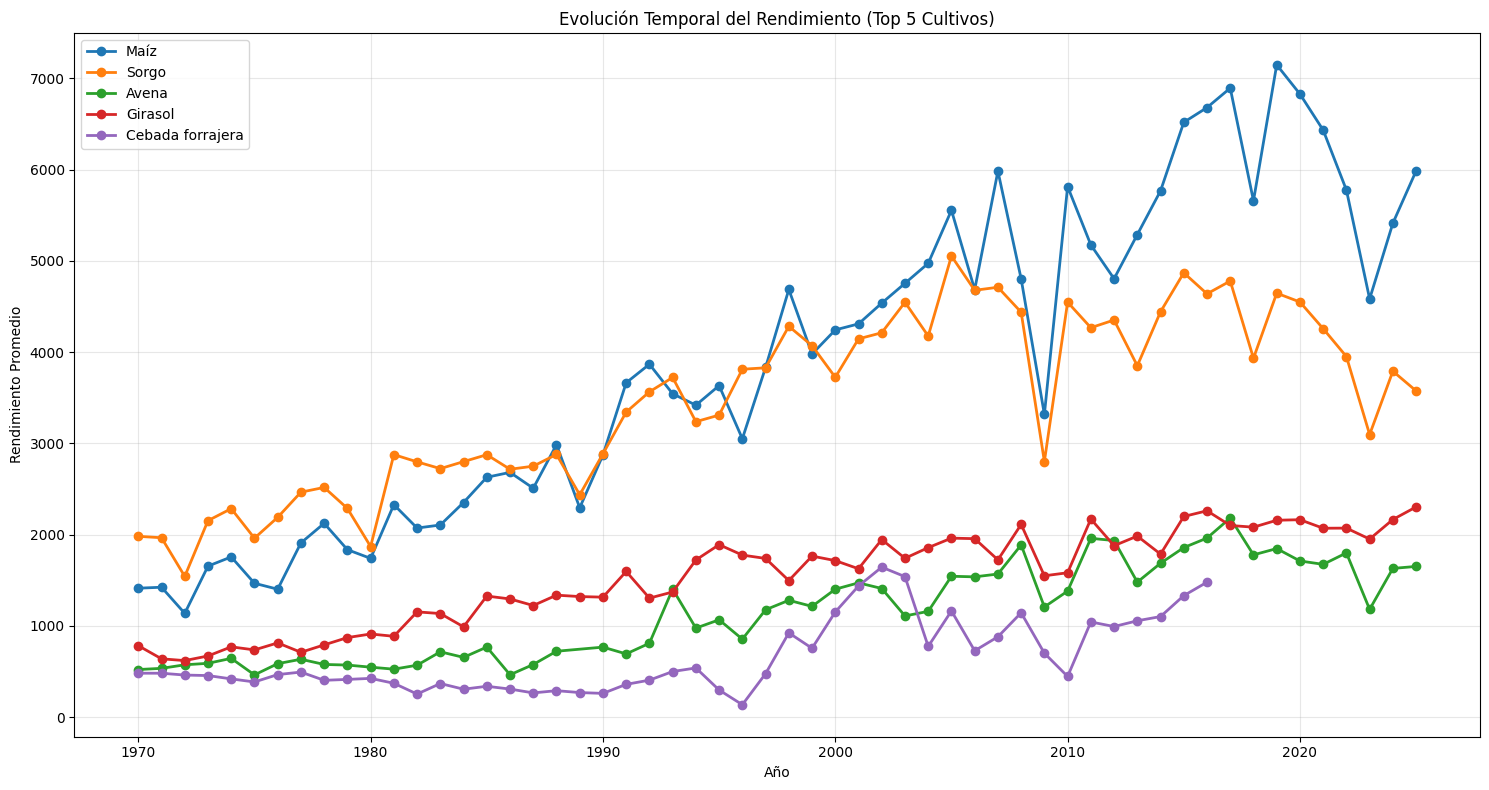

In [72]:
# Evolución temporal de rendimiento por cultivo
print("="*80)
print("EVOLUCIÓN TEMPORAL DE RENDIMIENTO POR CULTIVO")
print("="*80)

if 'cultivo' in categorical_features and 'año' in numerical_features and 'rendimiento' in numerical_features:
    # Seleccionar top 5 cultivos
    top_5_cultivos = full_data['cultivo'].value_counts().head(5).index
    
    plt.figure(figsize=(15, 8))
    
    for cultivo in top_5_cultivos:
        data_cultivo = full_data[full_data['cultivo'] == cultivo]
        yearly_avg = data_cultivo.groupby('año')['rendimiento'].mean()
        plt.plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2, label=cultivo)
    
    plt.xlabel('Año')
    plt.ylabel('Rendimiento Promedio')
    plt.title('Evolución Temporal del Rendimiento (Top 5 Cultivos)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Análisis Geográfico

In [73]:
# Análisis por provincia
print("="*80)
print("ANÁLISIS POR PROVINCIA")
print("="*80)

if 'provincia_nombre' in categorical_features:
    print(f"\nNúmero de provincias: {full_data['provincia_nombre'].nunique()}")
    print(f"\nRegistros por provincia:")
    provincia_counts = full_data['provincia_nombre'].value_counts().sort_values(ascending=False)
    print(provincia_counts.to_string())
    
    if 'rendimiento' in numerical_features:
        print("\n" + "="*80)
        print("RENDIMIENTO PROMEDIO POR PROVINCIA")
        print("="*80)
        
        rendimiento_provincia = full_data.groupby('provincia_nombre')['rendimiento'].agg([
            ('count', 'count'),
            ('mean', 'mean'),
            ('median', 'median'),
            ('std', 'std')
        ]).sort_values('mean', ascending=False)
        
        print(rendimiento_provincia.to_string())

ANÁLISIS POR PROVINCIA

Número de provincias: 23

Registros por provincia:
provincia_nombre
Buenos Aires           488806
Santa Fe               114258
Cordoba                106600
Corrientes              85464
La Pampa                84720
Chaco                   84378
Entre Rios              79658
Misiones                77286
Santiago Del Estero     63866
Salta                   48722
Tucuman                 45986
San Luis                30370
Formosa                 25124
Jujuy                   23772
Catamarca               21136
Mendoza                 19500
San Juan                14904
Rio Negro                9360
Neuquen                  6396
Chubut                   5712
Santa Cruz               3624
La Rioja                 2208
Tierra Del Fuego           84

RENDIMIENTO PROMEDIO POR PROVINCIA
                      count         mean  median           std
provincia_nombre                                              
Jujuy                 23772  9423.560575  2500.0  18775.

VISUALIZACIÓN: RENDIMIENTO POR PROVINCIA


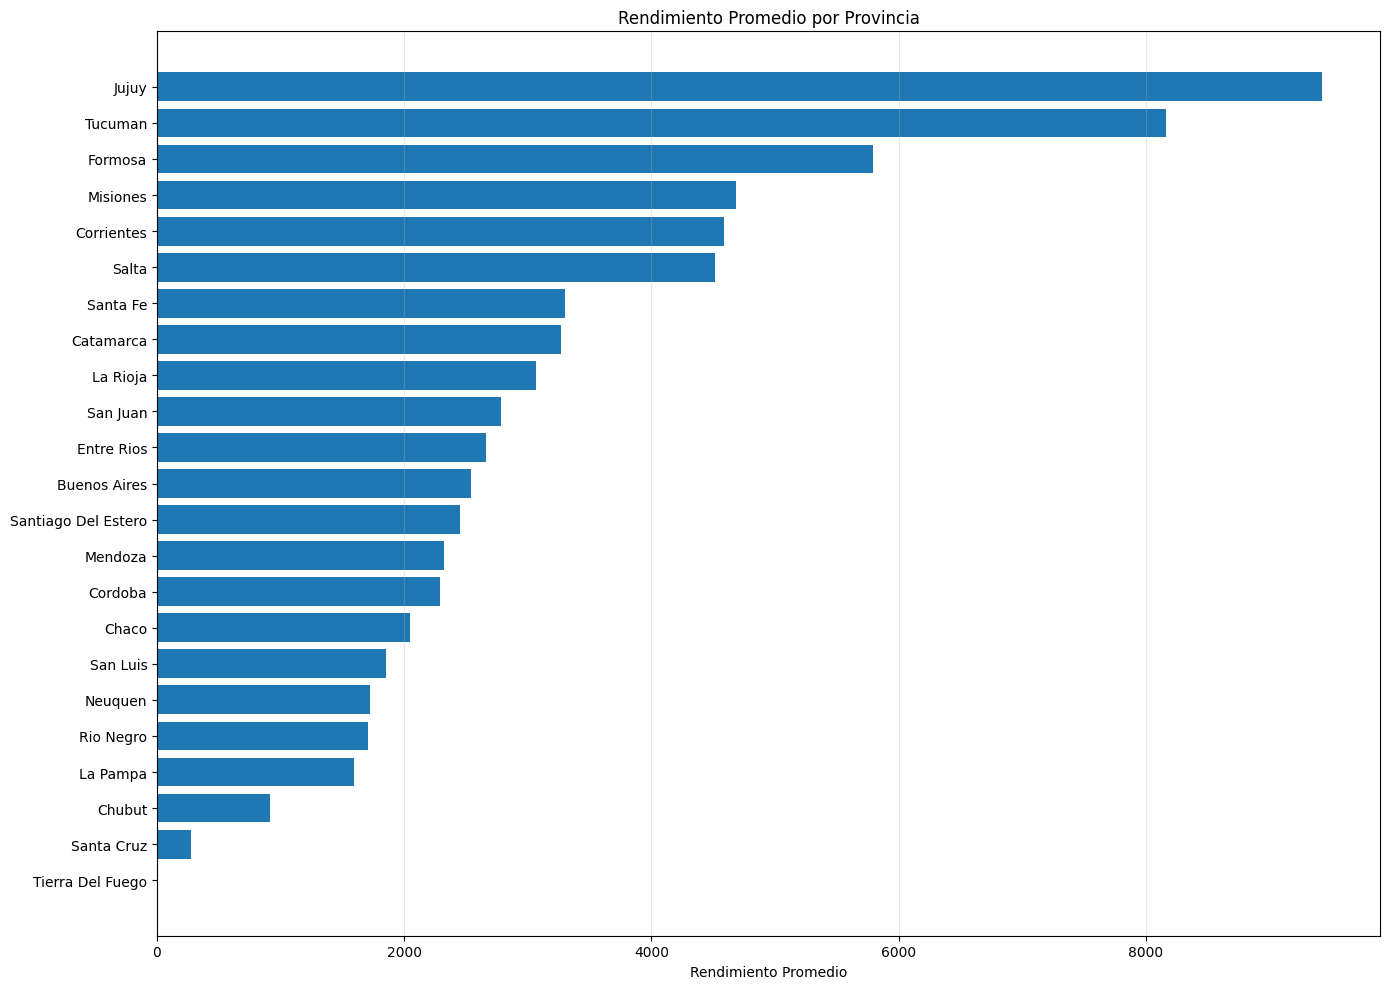

In [74]:
# Visualización geográfica - Rendimiento por provincia
print("="*80)
print("VISUALIZACIÓN: RENDIMIENTO POR PROVINCIA")
print("="*80)

if 'provincia_nombre' in categorical_features and 'rendimiento' in numerical_features:
    # Barplot de rendimiento promedio por provincia
    plt.figure(figsize=(14, 10))
    
    avg_rendimiento = full_data.groupby('provincia_nombre')['rendimiento'].mean().sort_values(ascending=True)
    
    plt.barh(range(len(avg_rendimiento)), avg_rendimiento.values)
    plt.yticks(range(len(avg_rendimiento)), avg_rendimiento.index)
    plt.xlabel('Rendimiento Promedio')
    plt.title('Rendimiento Promedio por Provincia')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

ANÁLISIS POR DEPARTAMENTO

Número de departamentos: 405

Top 15 departamentos por rendimiento promedio:
                     count          mean
departamento_nombre                     
LEDESMA               3592  15786.673719
YERBA BUENA            262  12684.671756
ORAN                  4602  12343.182964
SANTA BARBARA         4510  11322.031929
FAMAILLA              3080  11296.498701
MONTEROS              2950  11220.893559
RINCONADA               24  11111.000000
EL CARMEN             4272  10878.463015
CHICLIGASTA           3526   9515.560976
TAFI DEL VALLE        3370   9331.388724
RIO CHICO             3766   8729.104620
LULES                  478   8134.953975
TAFI VIEJO             418   8099.578947
BURRUYACU             5426   7376.688168
CRUZ ALTA             5334   7284.235471


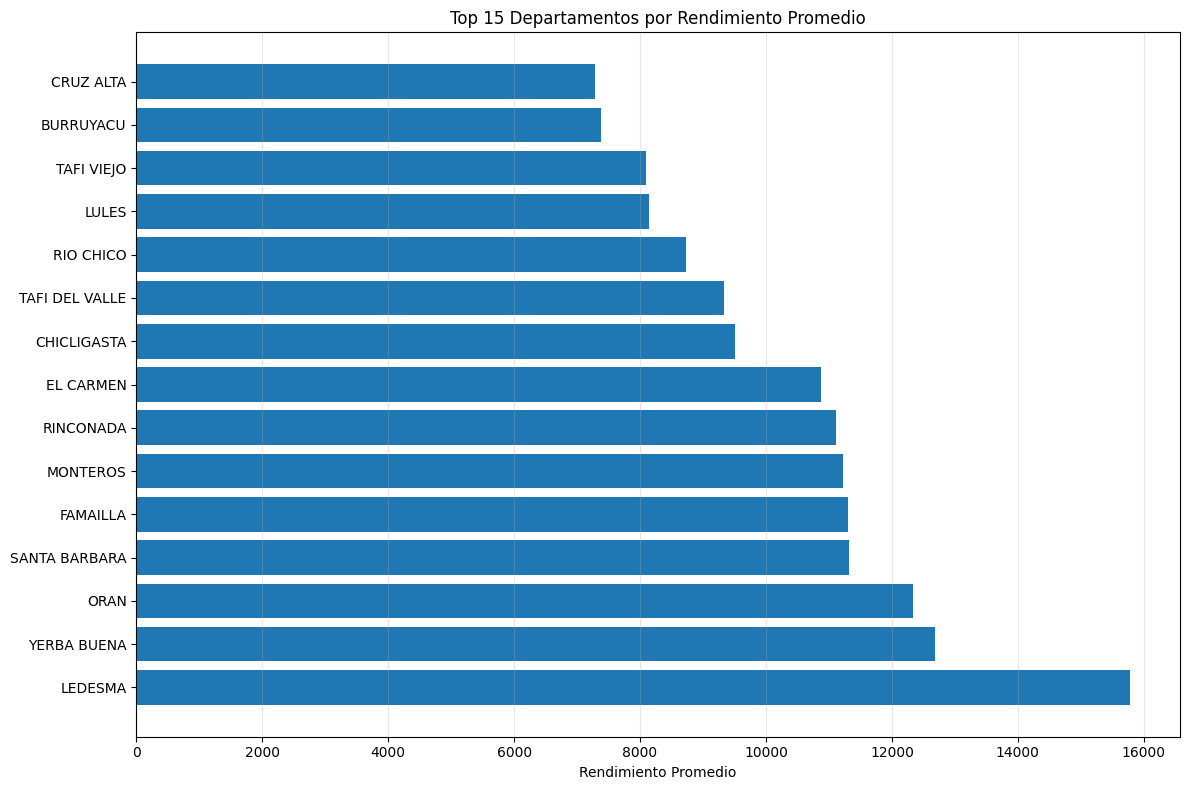

In [75]:
# Análisis de departamentos
print("="*80)
print("ANÁLISIS POR DEPARTAMENTO")
print("="*80)

if 'departamento_nombre' in categorical_features:
    print(f"\nNúmero de departamentos: {full_data['departamento_nombre'].nunique()}")
    
    if 'rendimiento' in numerical_features:
        # Top 15 departamentos por rendimiento
        top_deptos = full_data.groupby('departamento_nombre')['rendimiento'].agg([
            ('count', 'count'),
            ('mean', 'mean')
        ]).sort_values('mean', ascending=False).head(15)
        
        print("\nTop 15 departamentos por rendimiento promedio:")
        print(top_deptos.to_string())
        
        # Visualización
        plt.figure(figsize=(12, 8))
        plt.barh(range(len(top_deptos)), top_deptos['mean'].values)
        plt.yticks(range(len(top_deptos)), top_deptos.index)
        plt.xlabel('Rendimiento Promedio')
        plt.title('Top 15 Departamentos por Rendimiento Promedio')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

## 9. Análisis de Variables Climáticas y Edáficas

RELACIÓN ENTRE CLIMA Y RENDIMIENTO


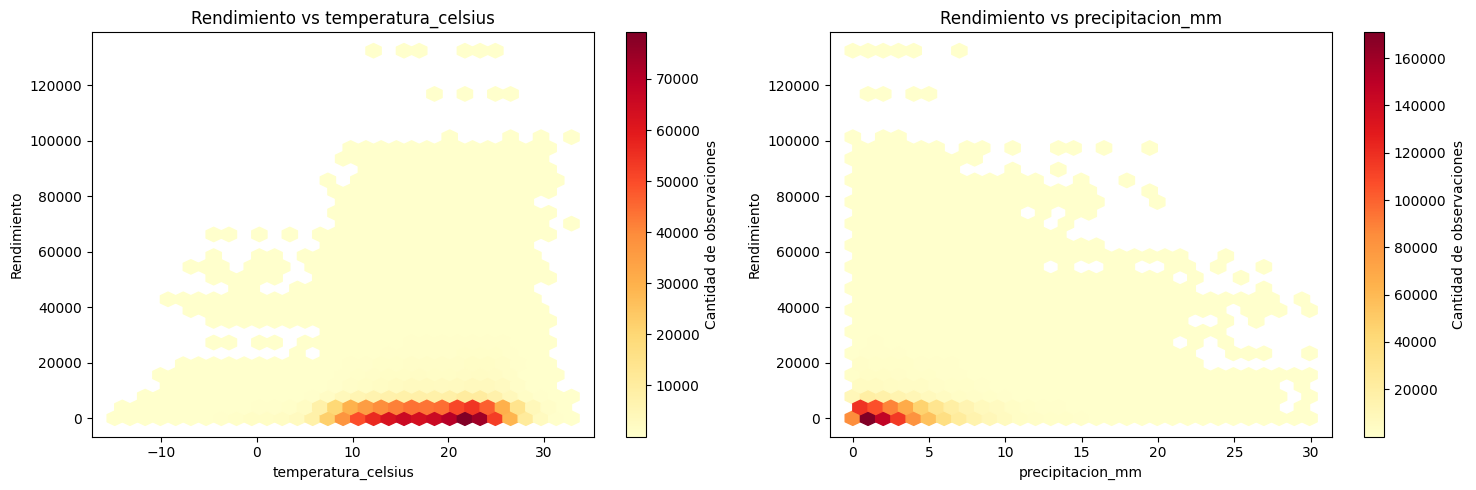

In [76]:
# Análisis de relación clima-rendimiento
print("="*80)
print("RELACIÓN ENTRE CLIMA Y RENDIMIENTO")
print("="*80)

clima_vars = ['temperatura_celsius', 'precipitacion_mm']
clima_available = [v for v in clima_vars if v in numerical_features]

if len(clima_available) > 0 and 'rendimiento' in numerical_features:
    fig, axes = plt.subplots(1, len(clima_available), figsize=(15, 5))
    
    if len(clima_available) == 1:
        axes = [axes]
    
    for idx, var in enumerate(clima_available):
        # Filtrar datos válidos
        data_clean = full_data[[var, 'rendimiento']].dropna()
        
        # Hexbin plot para manejar muchos puntos
        hb = axes[idx].hexbin(data_clean[var], data_clean['rendimiento'], 
                             gridsize=30, cmap='YlOrRd', mincnt=1)
        axes[idx].set_xlabel(var)
        axes[idx].set_ylabel('Rendimiento')
        axes[idx].set_title(f'Rendimiento vs {var}')
        plt.colorbar(hb, ax=axes[idx], label='Cantidad de observaciones')
    
    plt.tight_layout()
    plt.show()

ANÁLISIS DE VARIABLES EDÁFICAS (SUELO)

Variables de suelo encontradas: ['suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1']

Estadísticas de variables de suelo:
                      count       mean        std        min        25%        50%        75%         max
suelo_ind_prod    1441934.0  29.299887   7.962957   9.129310  21.090000  34.550898  34.550898   48.257353
suelo_porc_sue1   1441934.0  65.846856   8.890645  49.300699  62.190083  66.545659  66.699438   87.000000
suelo_profund_s1  1441934.0  96.075690  71.523446  52.409639  74.961538  77.879491  82.157025  389.510490

CORRELACIÓN DE VARIABLES DE SUELO CON RENDIMIENTO
suelo_profund_s1    0.066852
suelo_ind_prod     -0.015517
suelo_porc_sue1    -0.179211


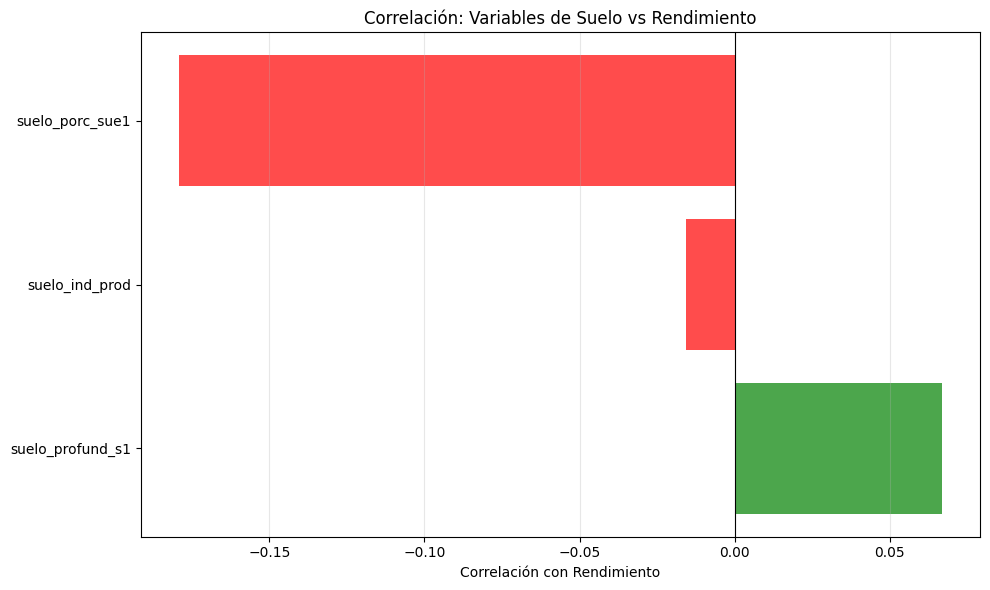

In [77]:
# Análisis de variables de suelo
print("="*80)
print("ANÁLISIS DE VARIABLES EDÁFICAS (SUELO)")
print("="*80)

suelo_vars = [col for col in numerical_features if 'suelo' in col.lower()]

if len(suelo_vars) > 0:
    print(f"\nVariables de suelo encontradas: {suelo_vars}")
    
    # Estadísticas
    print("\nEstadísticas de variables de suelo:")
    print(full_data[suelo_vars].describe().T.to_string())
    
    if 'rendimiento' in numerical_features and len(suelo_vars) > 0:
        print("\n" + "="*80)
        print("CORRELACIÓN DE VARIABLES DE SUELO CON RENDIMIENTO")
        print("="*80)
        
        suelo_corr = full_data[suelo_vars + ['rendimiento']].corr()['rendimiento'].drop('rendimiento').sort_values(ascending=False)
        print(suelo_corr.to_string())
        
        # Visualización
        plt.figure(figsize=(10, 6))
        colors = ['green' if x > 0 else 'red' for x in suelo_corr.values]
        plt.barh(range(len(suelo_corr)), suelo_corr.values, color=colors, alpha=0.7)
        plt.yticks(range(len(suelo_corr)), suelo_corr.index)
        plt.xlabel('Correlación con Rendimiento')
        plt.title('Correlación: Variables de Suelo vs Rendimiento')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

## 10. Conclusiones del EDA

### 📊 Resumen de Hallazgos Principales

#### 1. **Estructura del Dataset**
- Dataset de gran escala con información histórica extensa
- Combina datos agrícolas, climáticos y edáficos
- Granularidad temporal: mensual

#### 2. **Calidad de Datos**
- Verificar valores faltantes (especialmente en variables climáticas)
- Presencia de outliers en variables numéricas
- Necesidad de limpieza y preprocesamiento

#### 3. **Variables Relevantes para Predicción**
- **Variables climáticas**: Temperatura y precipitación muestran relación con rendimiento
- **Variables edáficas**: Índice de productividad del suelo relevante
- **Variables temporales**: Tendencias y estacionalidad observables

#### 4. **Insights por Cultivo**
- Diferentes cultivos tienen rendimientos muy distintos
- Cada cultivo responde diferente a condiciones climáticas
- Necesidad de modelado específico por cultivo o cultivo como feature

#### 5. **Variabilidad Geográfica**
- Grandes diferencias de rendimiento entre provincias
- Departamentos con características propias
- Información geográfica importante para el modelo

#### 6. **Consideraciones para Modelado**
- División temporal train/val/test (≤2010 / 2011-2016 / ≥2017)
- Feature engineering: variables climáticas agregadas, interacciones
- Manejo de valores faltantes en clima (36.5%)
- Normalización/estandarización de features
- Encoding de variables categóricas (provincia, departamento, cultivo)

### 🎯 Próximos Pasos Recomendados

1. **Preprocesamiento**:
   - Decidir estrategia para valores faltantes en clima
   - Tratamiento de outliers
   - Normalización de variables numéricas

2. **Feature Engineering**:
   - Variables climáticas agregadas (promedios trimestrales, acumulados)
   - Interacciones entre temperatura y precipitación
   - Variables lag (valores históricos)
   - Encoding de variables categóricas

3. **Modelado**:
   - Baseline: Mean histórica por grupo
   - Modelos lineales (Ridge, Lasso)
   - Gradient Boosting (XGBoost, LightGBM)
   - Validación temporal estricta

4. **Evaluación**:
   - Métricas: MAE, RMSE, R², MAPE
   - Análisis de residuos
   - Feature importance

---

**EDA Completado** ✅

In [78]:
# Resumen final de estadísticas clave
print("="*80)
print("RESUMEN EJECUTIVO - EDA COMPLETADO")
print("="*80)

print(f"\n📊 DATASET:")
print(f"  Dimensiones: {full_data.shape[0]:,} registros × {full_data.shape[1]} columnas")
print(f"  Memoria: {full_data.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

if 'año' in full_data.columns:
    print(f"\n📅 COBERTURA TEMPORAL:")
    print(f"  Años: {full_data['año'].min()} - {full_data['año'].max()}")
    print(f"  Duración: {full_data['año'].max() - full_data['año'].min() + 1} años")

if 'provincia_nombre' in categorical_features:
    print(f"\n🗺️ COBERTURA GEOGRÁFICA:")
    print(f"  Provincias: {full_data['provincia_nombre'].nunique()}")
if 'departamento_nombre' in categorical_features:
    print(f"  Departamentos: {full_data['departamento_nombre'].nunique()}")

if 'cultivo' in categorical_features:
    print(f"\n🌾 CULTIVOS:")
    print(f"  Tipos de cultivo: {full_data['cultivo'].nunique()}")
    print(f"  Top 5: {list(full_data['cultivo'].value_counts().head(5).index)}")

if 'rendimiento' in numerical_features:
    print(f"\n🎯 VARIABLE OBJETIVO (Rendimiento):")
    rend_stats = full_data['rendimiento'].describe()
    print(f"  Media: {rend_stats['mean']:.2f}")
    print(f"  Mediana: {full_data['rendimiento'].median():.2f}")
    print(f"  Std: {rend_stats['std']:.2f}")
    print(f"  Rango: [{rend_stats['min']:.2f}, {rend_stats['max']:.2f}]")

missing_total = full_data.isnull().sum().sum()
print(f"\n⚠️ VALORES FALTANTES:")
print(f"  Total: {missing_total:,}")
missing_cols = full_data.isnull().sum()[full_data.isnull().sum() > 0]
if len(missing_cols) > 0:
    print(f"  Columnas afectadas: {len(missing_cols)}")
    for col in missing_cols.index:
        pct = 100 * missing_cols[col] / len(full_data)
        print(f"    - {col}: {pct:.1f}%")

print(f"\n{'='*80}")
print("✅ EDA COMPLETADO - Listo para Feature Engineering y Modelado")
print("="*80)

RESUMEN EJECUTIVO - EDA COMPLETADO

📊 DATASET:
  Dimensiones: 1,441,934 registros × 15 columnas
  Memoria: 534.82 MB

📅 COBERTURA TEMPORAL:
  Años: 1970 - 2025
  Duración: 56 años

🗺️ COBERTURA GEOGRÁFICA:
  Provincias: 23
  Departamentos: 405

🌾 CULTIVOS:
  Tipos de cultivo: 34
  Top 5: ['Maíz', 'Sorgo', 'Avena', 'Girasol', 'Cebada forrajera']

🎯 VARIABLE OBJETIVO (Rendimiento):
  Media: 3126.65
  Mediana: 1800.00
  Std: 5319.14
  Rango: [0.00, 132405.00]

⚠️ VALORES FALTANTES:
  Total: 0

✅ EDA COMPLETADO - Listo para Feature Engineering y Modelado
